# Финальный проект Часть 2: Исследовательский анализ данных в Python и проверка гипотез.
- Автор: Сажина Наталья
- Дата: 16.07.2025
## Описание проекта
### Цели и задачи проекта

**Цель проекта:** выявить особенности и причины изменений в поведении пользователей сервиса Яндекс.Афиша в период с 2024-06-01 по 2024-10-31.

**Задачи проекта:**

1. Загрузить и подготовить данные.
2. Провести анализ распределения заказов по сегментам и их сезонные изменений.
3. Отдельно за период с 2024-09-01 по 2024-10-31 проанализовать динамику изменений:
* общего числа заказов,
* DAU,
* среднего числа заказов на одного пользователя,
* средней стоимости одного билета.
4. Изучить недельную цикличность пользовательской активности.
5. Выявить ключевые регионы и партнеров, которые вносят наибольший вклад в выручку.
6. Проверить две гипотезы:
* Среднее количество заказов на одного пользователя мобильного приложения выше по сравнению с пользователями стационарных устройств.
* Среднее время между заказами пользователей мобильных приложений выше по сравнению с пользователями стационарных устройств.

### Содержание
1. Описание проекта
2. Загрузка и обзор данных
3. Предобработка данных и подготовка их к исследованию
4. Исследовательский анализ данных
5. Статистический анализ данных
6. Общий вывод и рекомендации

### Описание данных

1. Датасет `final_tickets_orders_df.csv` включает информацию обо всех заказах билетов, совершённых с двух типов устройств — мобильных и стационарных. Поля датасета соответствуют таблице purchases, с которой вы работали в предыдущих заданиях:

`order_id` — уникальный идентификатор заказа.

`user_id` — уникальный идентификатор пользователя.

`created_dt_msk` — дата создания заказа (московское время).

`created_ts_msk` — дата и время создания заказа (московское время).

`event_id` — идентификатор мероприятия из таблицы events.

`cinema_circuit` — сеть кинотеатров. Если не применимо, то здесь будет значение 'нет'.

`age_limit` — возрастное ограничение мероприятия.

`currency_code` — валюта оплаты, например rub для российских рублей.

`device_type_canonical` — тип устройства, с которого был оформлен заказ, например mobile для мобильных устройств, desktop для стационарных.

`revenue` — выручка от заказа.

`service_name` — название билетного оператора.

`tickets_count` — количество купленных билетов.

`total` — общая сумма заказа.

`days_since_prev` - количество дней с предыдущей покупки для каждого пользователя. Если покупки не было, то данные содержат пропуск.

2. Датасет final_tickets_events_df содержит информацию о событиях, включая город и регион события, а также информацию о площадке проведения мероприятия. Обратите внимание, что из данных исключили фильмы, ведь, как было видно на дашборде, событий такого типа не так много. Датасет содержит такие поля:

`event_id` — уникальный идентификатор мероприятия.

`event_name` — название мероприятия. Аналог поля event_name_code из исходной базы данных.

`event_type_description` — описание типа мероприятия.

`event_type_main` — основной тип мероприятия: театральная постановка, концерт и так далее.

`organizers` — организаторы мероприятия.

`region_name` — название региона.

`city_name` — название города.

`venue_id` — уникальный идентификатор площадки.

`venue_name` — название площадки.

`venue_address` — адрес площадки.

3. Датасет final_tickets_tenge_df.csv с информацией о курсе тенге к российскому рублю за 2024 год. Значения в рублях представлено для 100 тенге. Датасет содержит такие поля:

`nominal` — номинал (100 тенге).

`data` — дата.

`curs` — курс тенге к рублю.

`cdx` — обозначение валюты (kzt).

## Загрузка и обзор данных



In [1]:
#импортируем все необходимые библиотеки и модули
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.stats.power import NormalIndPower
from scipy import stats as st
from statsmodels.stats.proportion import proportion_effectsize
from math import ceil
from scipy.stats import ttest_ind
from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import mannwhitneyu

In [2]:
df_orders = pd.read_csv('/datasets/final_tickets_orders_df.csv')
display(df_orders.head())
df_orders.info()

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,service_name,tickets_count,total,days_since_prev
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.94,Край билетов,4,10870.99,NaN
1,7965605,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,237325,нет,0,rub,mobile,289.45,Мой билет,2,2067.51,NaN
2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,нет,0,rub,mobile,1258.57,За билетом!,4,13984.16,75.0
3,1139875,000898990054619,2024-07-13,2024-07-13 19:40:48,387271,нет,0,rub,mobile,8.49,Лови билет!,2,212.28,NaN
4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,нет,18,rub,mobile,1390.41,Билеты без проблем,3,10695.43,83.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290849 entries, 0 to 290848
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   order_id               290849 non-null  int64  
 1   user_id                290849 non-null  object 
 2   created_dt_msk         290849 non-null  object 
 3   created_ts_msk         290849 non-null  object 
 4   event_id               290849 non-null  int64  
 5   cinema_circuit         290849 non-null  object 
 6   age_limit              290849 non-null  int64  
 7   currency_code          290849 non-null  object 
 8   device_type_canonical  290849 non-null  object 
 9   revenue                290849 non-null  float64
 10  service_name           290849 non-null  object 
 11  tickets_count          290849 non-null  int64  
 12  total                  290849 non-null  float64
 13  days_since_prev        268909 non-null  float64
dtypes: float64(3), int64(4), object(7)
m

В датасете с даными о заказах 290849 строк и 14 столбцов. Пропуски имеются только в столбце `days_since_prev`, что допустимо т.к. для строк с первым заказом пользователя значение этого столбца должно быть пустым. 

Необходимо изменить формат данных для столбцов:
* `created_dt_msk` и `created_ts_msk` - привести к формату datetime64;
* `days_since_prev` - привести к формату int и оптимизировать битность;
* `tickets_count` - Оптимизировать битность для увеличения производительности.

In [3]:
df_events = pd.read_csv('/datasets/final_tickets_events_df.csv')
display(df_events.head())
df_events.info()

,event_id,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
0,4436,e4f26fba-da77-4c61-928a-6c3e434d793f,спектакль,театр,№4893,Североярская область,Озёрск,2,1600,"Кладбище искусств ""Проблема"" и партнеры","наб. Загородная, д. 785"
1,5785,5cc08a60-fdea-4186-9bb2-bffc3603fb77,спектакль,театр,№1931,Светополянский округ,Глиноград,54,2196,"Лекции по искусству ""Свет"" Групп","ул. Ягодная, д. 942"
2,8817,8e379a89-3a10-4811-ba06-ec22ebebe989,спектакль,театр,№4896,Североярская область,Озёрск,2,4043,"Кинокомитет ""Золотая"" Инк","ш. Коммуны, д. 92 стр. 6"
3,8849,682e3129-6a32-4952-9d8a-ef7f60d4c247,спектакль,театр,№4960,Каменевский регион,Глиногорск,213,1987,"Выставка ремесел ""Свет"" Лтд","пер. Набережный, д. 35"
4,8850,d6e99176-c77f-4af0-9222-07c571f6c624,спектакль,театр,№4770,Лесодальний край,Родниковец,55,4230,"Фестивальный проект ""Листья"" Групп","пер. Проезжий, д. 9"


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22427 entries, 0 to 22426
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   event_id                22427 non-null  int64 
 1   event_name              22427 non-null  object
 2   event_type_description  22427 non-null  object
 3   event_type_main         22427 non-null  object
 4   organizers              22427 non-null  object
 5   region_name             22427 non-null  object
 6   city_name               22427 non-null  object
 7   city_id                 22427 non-null  int64 
 8   venue_id                22427 non-null  int64 
 9   venue_name              22427 non-null  object
 10  venue_address           22427 non-null  object
dtypes: int64(3), object(8)
memory usage: 1.9+ MB


В датасете с данными о событиях 22427 строк и 11 столбцов, ни один из столбцов не содержит пропусков. 

Для увеличения производительности нужно оптимизировать битность столбцов `city_id` и `venue_id`.

In [4]:
df_curs = pd.read_csv('/datasets/final_tickets_tenge_df.csv')
display(df_curs.head())
df_curs.info()

,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     357 non-null    object 
 1   nominal  357 non-null    int64  
 2   curs     357 non-null    float64
 3   cdx      357 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 11.3+ KB


Датасет с курсом валют по дням имеет 357 строк и 4 столбца. Ни в одном из столбцов не содержатся пропуски. Необходимо пропусти столбец с датой к соответствующему типу  и оптимизировать битност ь столбца `nominal`.

**План предобработки данных:**
1. Изменение типов данных:
* `created_dt_msk` и `created_ts_msk` из `df_orders`, а так же `data` из `df_curs` - привести к формату datetime64;
* привести столбец `days_since_prev` к формату int;
* оптимизировать битность в столбцах `tickets_count`, `days_since_prev` из `df_orders`, `city_id` и `venue_id` из `df_events`, а так же `nominal` из `df_curs`.
2. Изучить значения в ключевых столбцах:
* категориальные столбцы (`age_limit`, `currency_code`, `device_type_canonical`, `service_name`, `event_type_main`, `organizers`, `region_name`, `city_name`, `venue_name`,`venue_id`) - проверить, встречаются ли значения, которые могут обозначать пропуски в данных или отсутствие информации. Нормализировать данные, если это необходимо.
* количественные значения (`revenue`, `tickets_count`) - изучить распределение и выбросы при их наличии. 
3. Проверить данные на наличие янвых и неявных дубликатов. При необходимости обработать из оптимальным способом.
4. Создать несколько новых столбцов:
* `revenue_rub` — выручка с заказа в единой валюте — российском рубле. 
* `one_ticket_revenue_rub` — выручка с продажи одного билета на мероприятие.
* `month` — месяц оформления заказа.
* `season` — столбец с информацией о сезонности, включая такие категории, как: 'лето', 'осень', 'зима', 'весна'.

## Предобработка данных
### Изменение типов данных
Сначала объединим данные о заказах и событиях в один датафрейм, после проведем изменение типов данных. Изменение типов данных:
* `created_dt_msk` и `created_ts_msk` из `df_orders`, а так же `data` из `df_curs` - привести к формату datetime64;
* привести столбец `days_since_prev` к формату int;
* оптимизировать битность в столбцах `tickets_count`, `days_since_prev` из `df_orders`, `city_id` и `venue_id` из `df_events`, а так же `nominal` из `df_curs`.

In [5]:
merged = df_orders.merge(df_events, how = 'left', on = 'event_id')


for col in ['created_dt_msk', 'created_ts_msk']:
    merged[col] = pd.to_datetime(merged[col])
    
    
col_list_downcast = ['tickets_count', 'city_id', 'venue_id']
for col in col_list_downcast:
    merged[col] = pd.to_numeric(merged[col], downcast = 'integer')    
    
merged.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 290849 entries, 0 to 290848
Data columns (total 24 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   order_id                290849 non-null  int64         
 1   user_id                 290849 non-null  object        
 2   created_dt_msk          290849 non-null  datetime64[ns]
 3   created_ts_msk          290849 non-null  datetime64[ns]
 4   event_id                290849 non-null  int64         
 5   cinema_circuit          290849 non-null  object        
 6   age_limit               290849 non-null  int64         
 7   currency_code           290849 non-null  object        
 8   device_type_canonical   290849 non-null  object        
 9   revenue                 290849 non-null  float64       
 10  service_name            290849 non-null  object        
 11  tickets_count           290849 non-null  int8          
 12  total                   290849

In [6]:
df_curs_types = df_curs

df_curs_types['data'] = pd.to_datetime(df_curs_types['data'])

df_curs_types['nominal'] = pd.to_numeric(df_curs_types['nominal'], downcast = 'integer')


df_curs_types.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   data     357 non-null    datetime64[ns]
 1   nominal  357 non-null    int8          
 2   curs     357 non-null    float64       
 3   cdx      357 non-null    object        
dtypes: datetime64[ns](1), float64(1), int8(1), object(1)
memory usage: 8.8+ KB


После объединения двух основных датафреймов и изменения типов данных в столбцах имеем два датасета:
1. `merged` - с объединенными данными о заказах и мероприятиях, 290849 строк и 24 столбца. 
2. `df_curs_types` - с курсом тенге к рублю по датам, 357 строк и 4 столбца.

### Значения в ключевых столбцах
1. **Категориальные столбцы** (currency_code, device_type_canonical, service_name, event_type_main, region_name) - проверим, встречаются ли значения, которые могут обозначать пропуски в данных или отсутствие информации. Нормализировать данные, если это необходимо.

In [7]:
currencies = merged.value_counts('currency_code')
currencies

currency_code
rub    285780
kzt      5069
dtype: int64

In [8]:
devices = merged.value_counts('device_type_canonical')
devices

device_type_canonical
mobile     232679
desktop     58170
dtype: int64

In [9]:
services = merged.value_counts('service_name')
services

service_name
Билеты без проблем        63709
Лови билет!               41126
Билеты в руки             40364
Мой билет                 34843
Облачко                   26642
Лучшие билеты             17795
Весь в билетах            16849
Прачечная                 10273
Край билетов               6207
Тебе билет!                5228
Яблоко                     5039
Дом культуры               4502
За билетом!                2865
Городской дом культуры     2733
Show_ticket                2200
Мир касс                   2167
Быстробилет                2003
Выступления.ру             1616
Восьмёрка                  1118
Crazy ticket!               790
Росбилет                    539
Шоу начинается!             499
Быстрый кассир              381
Радио ticket                376
Телебилет                   321
КарандашРУ                  133
Реестр                      125
Билет по телефону            85
Вперёд!                      80
Дырокол                      74
Кино билет                 

In [10]:
event_types = merged.value_counts('event_type_main')
event_types

event_type_main
концерты    115276
театр        67321
другое       65867
спорт        21911
стендап      13393
выставки      4854
ёлки          1989
dtype: int64

In [11]:
regions = merged.value_counts('region_name')
regions.head(40)

region_name
Каменевский регион           91058
Североярская область         44049
Широковская область          16457
Медовская область            13901
Озернинский край             10476
Светополянский округ          7607
Малиновоярский округ          6618
Речиновская область           6293
Солнечноземская область       6288
Яблоневская область           6181
Серебринская область          5610
Горицветская область          5166
Травяная область              5045
Лугоградская область          4701
Тепляковская область          4389
Солнечнореченская область     3996
Глиногорская область          3214
Зоринский регион              3214
Шанырский регион              2882
Чистогорская область          2686
Лесодальний край              2577
Верхоречная область           2387
Заречная область              2160
Травиницкий округ             1779
Ветренский регион             1768
Боровлянский край             1721
Каменноозёрный край           1658
Речицкий регион               1590
Каменноя

Значения в важных для анализа категориальных столбцах не содержат заполняющих значений(вместо пропусков) или неявных дубликатов и не требуют нормализации.

2. Проверим **количественные значения (revenue, tickets_count)** - распределение и выбросы при их наличии.

In [12]:
merged['revenue'].describe()

count    290849.000000
mean        625.083054
std        1227.316214
min         -90.760000
25%         116.790000
50%         355.340000
75%         809.750000
max       81174.540000
Name: revenue, dtype: float64

Имеются отрицательные значения выручки. Это может быть реальная работа с убытком - вызванная некоторой маркетингововй активностью или ошибка в данных. Если это действительно убыточные заказы - общая сумма заказа `total` должна быть положительным числом, проверим

In [13]:
real_negative_revenue = merged[(merged['revenue'] < 0) & (merged['total'] > 0)]

real_negative_revenue


,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,...,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address


Для всех заказов с отрицательной выручкой общая сумма заказа так же является отрицательной, это явная ошибка в сборе данных, уточним долю таких строк от общего количества заказов

In [14]:
negative_share = round(merged[merged['revenue'] < 0].shape[0] / merged.shape[0] * 100, 2)

negative = merged[merged['revenue'] < 0].shape[0]

display(f'Количество заказов с отрицательной выручкой составляет {negative}, это {negative_share}% от общего количества заказов')

'Количество заказов с отрицательной выручкой составляет 381, это 0.13% от общего количества заказов'

In [15]:
# т.к. заказов с ошибочной выручкой всего 0.13% и у нас нет возможности выяснить причину ошибки - не будем рассматривать данные об этих заказах в анал
merged_df = merged[merged['revenue'] >= 0]
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 290468 entries, 0 to 290848
Data columns (total 24 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   order_id                290468 non-null  int64         
 1   user_id                 290468 non-null  object        
 2   created_dt_msk          290468 non-null  datetime64[ns]
 3   created_ts_msk          290468 non-null  datetime64[ns]
 4   event_id                290468 non-null  int64         
 5   cinema_circuit          290468 non-null  object        
 6   age_limit               290468 non-null  int64         
 7   currency_code           290468 non-null  object        
 8   device_type_canonical   290468 non-null  object        
 9   revenue                 290468 non-null  float64       
 10  service_name            290468 non-null  object        
 11  tickets_count           290468 non-null  int8          
 12  total                   290468

После удаления 381 строки с отрицательной выручкой мы получили датасе с данными о заказах  и событиях с 290468 строками.

In [16]:
merged_df['revenue'].describe()

count    290468.000000
mean        625.906230
std        1227.910242
min           0.000000
25%         116.990000
50%         356.300000
75%         810.410000
max       81174.540000
Name: revenue, dtype: float64

In [17]:
#кроме отрицательных значений есть еще заказы с нулевой выручкой, проверим их по такому же алгоритму
real_null_revenue = merged[(merged['revenue'] == 0) & (merged['total'] > 0)]
null_revenue = merged[merged['revenue'] == 0]


display(real_null_revenue[['order_id','revenue','total','tickets_count']])
display(f'Всего заказов с нулевой выручкой {null_revenue.shape[0]} из них {real_null_revenue.shape[0]} имеют общую сумму заказа больше нуля')

,order_id,revenue,total,tickets_count
8297,6478166,0.0,2054.19,3
10643,5492340,0.0,2108.20,4
70403,1184999,0.0,2108.20,4
70404,1184970,0.0,1581.15,3
70405,1184912,0.0,1054.10,2
70408,1185057,0.0,6618.35,4
75268,7243882,0.0,6618.35,4
94245,3018959,0.0,8272.94,5
125517,6731394,0.0,1906.44,3
125696,2415585,0.0,2054.19,3


'Всего заказов с нулевой выручкой 5737 из них 19 имеют общую сумму заказа больше нуля'

In [18]:
null_share = round(merged_df[(merged_df['revenue'] == 0) & (merged_df['total'] <= 0)].shape[0] / merged_df.shape[0] * 100, 2)

null_revenue = merged_df[(merged_df['revenue'] == 0) & (merged_df['total'] <= 0)].shape[0]

display(f'Количество заказов с нулевой выручкой и нулевой суммой заказа составляет {null_revenue}, это {null_share}% от общего количества заказов')

'Количество заказов с нулевой выручкой и нулевой суммой заказа составляет 5718, это 1.97% от общего количества заказов'

В целом возможно иметь часть заказов с ненулевой суммой и нулевой выручкой - это 19 строк оставим без изменений. 5718 строк с нулевой выручкой и нулевой суммой заказа придется удалить из датасета во избежание искажения результатов. Рекомендую выяснить, чем могло быть вызвано наличие таких заказов в датасете.  

In [19]:
df_nonull = merged_df[~((merged_df['revenue'] == 0) & (merged_df['total'] <= 0))]
display(df_nonull.info())
display(f'После удаления строк с нулевой выручкой и нулевой суммой заказа в датасете имеем {df_nonull.shape[0]} строк')

<class 'pandas.core.frame.DataFrame'>
Int64Index: 284750 entries, 0 to 290848
Data columns (total 24 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   order_id                284750 non-null  int64         
 1   user_id                 284750 non-null  object        
 2   created_dt_msk          284750 non-null  datetime64[ns]
 3   created_ts_msk          284750 non-null  datetime64[ns]
 4   event_id                284750 non-null  int64         
 5   cinema_circuit          284750 non-null  object        
 6   age_limit               284750 non-null  int64         
 7   currency_code           284750 non-null  object        
 8   device_type_canonical   284750 non-null  object        
 9   revenue                 284750 non-null  float64       
 10  service_name            284750 non-null  object        
 11  tickets_count           284750 non-null  int8          
 12  total                   284750

None

'После удаления строк с нулевой выручкой и нулевой суммой заказа в датасете имеем 284750 строк'

In [20]:
df_nonull['revenue'].describe()

count    284750.000000
mean        638.474911
std        1236.938119
min           0.000000
25%         127.410000
50%         369.320000
75%         823.930000
max       81174.540000
Name: revenue, dtype: float64

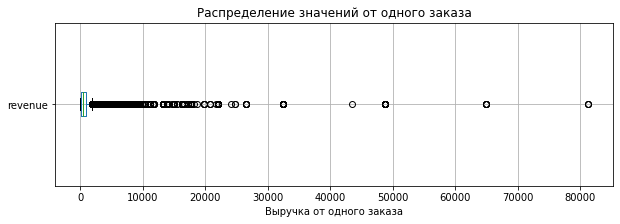

In [21]:
df_nonull.boxplot(column = 'revenue', figsize = (10,3), vert = False)

plt.xlabel('Выручка от одного заказа')
plt.title('Распределение значений от одного заказа')
plt.show()

В столбце `revenue` есть несколько выбросов размером более 30 тыс. Возможно, это связано с различными валютами, создадим столбец, в котором вся выручка будет в рублях

In [22]:
df_nonull = df_nonull.rename(columns = {'created_dt_msk':'date'})
df_curs_types = df_curs_types.rename(columns = {'data':'date'})

orders_events_curs = df_nonull.merge(df_curs_types, on = 'date', how = 'left')

def create_rev_rub(row):
    """
    Функция создает новый столбец, в котором будет 
    указана выручка только в рублях для всех строк по курсу, соответствующему дате заказа
    """
    if row['currency_code'] == 'kzt':
        return row['revenue']/100*row['curs']
    else:
        return row['revenue']
        
orders_events_curs['revenue_rub'] = orders_events_curs.apply(create_rev_rub, axis = 1) 

kz = orders_events_curs[orders_events_curs['currency_code'] == 'kzt']

kz[['revenue','currency_code','curs','revenue_rub']].head()




,revenue,currency_code,curs,revenue_rub
68,518.10,kzt,19.0125,98.503762
87,347.18,kzt,18.9330,65.731589
94,328.77,kzt,18.5991,61.148261
274,22021.55,kzt,19.8928,4380.702898
457,7397.66,kzt,19.9833,1478.296591


In [23]:
# теперь у нас есть столбец с выручкой в рублях, можем удалить ненужные столбцы

df_rubs = orders_events_curs
df_rubs = df_rubs.drop('nominal', axis = 1)
df_rubs = df_rubs.drop('cdx', axis = 1)
df_rubs = df_rubs.drop('curs', axis = 1)
df_rubs.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 284750 entries, 0 to 284749
Data columns (total 25 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   order_id                284750 non-null  int64         
 1   user_id                 284750 non-null  object        
 2   date                    284750 non-null  datetime64[ns]
 3   created_ts_msk          284750 non-null  datetime64[ns]
 4   event_id                284750 non-null  int64         
 5   cinema_circuit          284750 non-null  object        
 6   age_limit               284750 non-null  int64         
 7   currency_code           284750 non-null  object        
 8   device_type_canonical   284750 non-null  object        
 9   revenue                 284750 non-null  float64       
 10  service_name            284750 non-null  object        
 11  tickets_count           284750 non-null  int8          
 12  total                   284750

In [24]:
df_rubs['revenue_rub'].describe()


count    284750.000000
mean        567.021475
std         880.781099
min           0.000000
25%         124.680000
50%         364.280000
75%         811.500000
max       81174.540000
Name: revenue_rub, dtype: float64

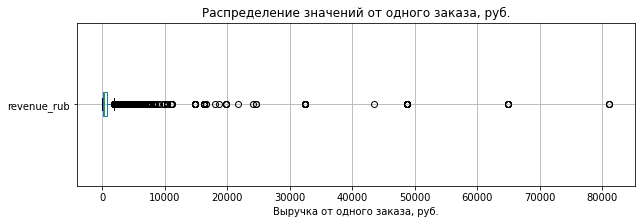

In [25]:
df_rubs.boxplot(column = 'revenue_rub', figsize = (10,3), vert = False)

plt.xlabel('Выручка от одного заказа, руб.')
plt.title('Распределение значений от одного заказа, руб.')
plt.show()

In [26]:
#причина наличия выбросов была не в валюте, рассмотрим их подробнее

fliers_revenue = df_rubs[df_rubs['revenue_rub'] > 30000]
display(fliers_revenue[['order_id','revenue_rub','event_id','total','region_name','tickets_count']])
display(f'Всего офомрлено {fliers_revenue.shape[0]} заказов с выручкой более 30000 рублей.')

,order_id,revenue_rub,event_id,total,region_name,tickets_count
10898,3329694,48704.72,552398,487047.22,Североярская область,3
28378,4874988,48704.72,552398,487047.22,Североярская область,3
42114,3992344,32469.82,552398,324698.16,Североярская область,2
42116,3992373,32469.82,552398,324698.16,Североярская область,2
49636,1495444,48704.72,552398,487047.22,Североярская область,3
50487,3246754,48704.72,552398,487047.22,Североярская область,3
67704,7150937,32469.82,552398,324698.16,Североярская область,2
77217,4008352,43515.08,547863,395591.62,Североярская область,2
86650,5568291,32469.82,552398,324698.16,Североярская область,2
92149,6703119,32469.82,552398,324698.16,Североярская область,2


'Всего офомрлено 53 заказов с выручкой более 30000 рублей.'

Видим, что все заказы с выручкой более 30 тыс рублей - на одно мероприятие (552398) в Североярской области. Необходимо выяснить, не является ли ошибкой такая явно завышенная сумма заказов на одно метроприятие. Пока для анализа распределения не будем учитывать эти заказы и в целом отсеем выбросы по 99 процентилю

In [27]:
fliers = df_rubs['revenue_rub'].quantile(0.99)

df_no_fliers = df_rubs[df_rubs['revenue_rub'] < fliers]

df_no_fliers['revenue_rub'].describe()


count    281743.000000
mean        527.456654
std         509.084456
min           0.000000
25%         122.440000
50%         357.920000
75%         796.330000
max        2627.000000
Name: revenue_rub, dtype: float64

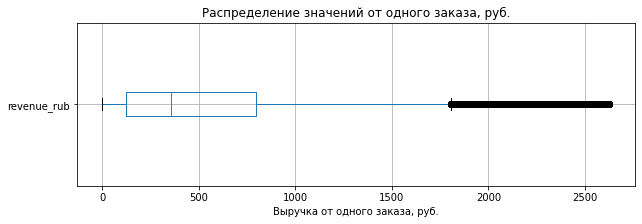

In [28]:
df_no_fliers.boxplot(column = 'revenue_rub', figsize = (10,3), vert = False)

plt.xlabel('Выручка от одного заказа, руб.')
plt.title('Распределение значений от одного заказа, руб.')
plt.show()

В результате после удаления явных выбросов для показателя выручки на один заказа в рублях мы видим ассиметричное распределение с центром близким к нулю и длинным правым хвостом. Половина значений находится в пределах от 122.44 руб. (первый квартиль) до 796.33 руб. (третий квартиль). Среднее значение больше медианного, что подтверждает картину наличия большого количества положительных выбросов. Размах значений соответствует максимальному значению и составляет 2627 руб.

In [29]:
display(df_no_fliers['tickets_count'].describe())


display('Чаще всего количество билетов в одном заказе:')
display(df_no_fliers['tickets_count'].mode()[0])       

count    281743.000000
mean          2.744015
std           1.157558
min           1.000000
25%           2.000000
50%           3.000000
75%           3.000000
max          47.000000
Name: tickets_count, dtype: float64

'Чаще всего количество билетов в одном заказе:'

3

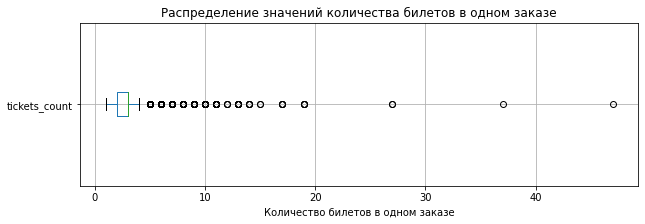

In [30]:
df_no_fliers.boxplot(column = 'tickets_count', figsize = (10,3), vert = False)

plt.xlabel('Количество билетов в одном заказе')
plt.title('Распределение значений количества билетов в одном заказе')
plt.show()

Распределения значений количества билетов на один заказ так же имеет ассиметричную форму и положительные выбросы. Основная масса значений плотно сгруппирована вокруг пика, стандартное отклонение составляет всего 1.15. Половина всех значений - это 2-3 билета в заказе. Максимальное значение - 47 билетов в заказе, что вполне реально, будем иметь в виду этот выброс без удаления.

### Работа с дубликатами

In [31]:
#проверим датасет на наличие явных дубликатов
dupl_count = df_no_fliers.duplicated().sum()

dupl_count

0

In [32]:
#явных дубликатов в датасете нет, проверим неявные
partial_dupl_count = df_no_fliers.duplicated(subset = ['user_id','date','event_id','device_type_canonical','created_ts_msk','revenue_rub','service_name','tickets_count','total']).sum()
partial_dupl_count

39

In [33]:
#найдено 39 дублей, выведем их для примера
df_sorted = df_no_fliers.sort_values(by = ['user_id','created_ts_msk','revenue_rub'])

duplicates = df_sorted[df_sorted.duplicated(subset = ['user_id','date','event_id','device_type_canonical','created_ts_msk','revenue_rub','service_name','tickets_count','total'], keep = False)]

duplicates

,order_id,user_id,date,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,...,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address,revenue_rub
11522,1123983,06eb7897f65b433,2024-08-13,2024-08-13 16:31:07,183706,нет,18,rub,mobile,69.82,...,спектакль,театр,№1482,Светополянский округ,Глиноград,54.0,4443.0,"Центр культурного наследия ""Объединение"" и пар...","бул. Карбышева, д. 50",69.82
11523,1123867,06eb7897f65b433,2024-08-13,2024-08-13 16:31:07,183706,нет,18,rub,mobile,69.82,...,спектакль,театр,№1482,Светополянский округ,Глиноград,54.0,4443.0,"Центр культурного наследия ""Объединение"" и пар...","бул. Карбышева, д. 50",69.82
26348,1930705,0dc525d7bacbb0d,2024-07-31,2024-07-31 13:26:11,393430,нет,18,rub,desktop,1556.05,...,концерт,концерты,№5048,Каменевский регион,Глиногорск,213.0,2704.0,"Летний фестиваль ""Симфония"" Лтд","бул. Боровой, д. 8/1 стр. 43",1556.05
26350,1930763,0dc525d7bacbb0d,2024-07-31,2024-07-31 13:26:11,393430,нет,18,rub,desktop,1556.05,...,концерт,концерты,№5048,Каменевский регион,Глиногорск,213.0,2704.0,"Летний фестиваль ""Симфония"" Лтд","бул. Боровой, д. 8/1 стр. 43",1556.05
52766,1935113,206ea45ec11d478,2024-10-29,2024-10-29 16:46:54,442183,нет,16,rub,mobile,601.69,...,концерт,концерты,№894,Каменевский регион,Глиногорск,213.0,4363.0,"Студия дизайна ""Лестница"" Лимитед","наб. Школьная, д. 9/8 стр. 7/5",601.69
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
279647,8547809,fd4d47438ebb946,2024-06-19,2024-06-19 15:40:56,489843,нет,18,rub,desktop,989.57,...,спектакль,театр,№1858,Каменевский регион,Глиногорск,213.0,4017.0,"Студия анимации ""Точка"" Инкорпорэйтед","алл. Тамбовская, д. 7 к. 827",989.57
279654,8548099,fd4d47438ebb946,2024-06-19,2024-06-19 15:40:56,489843,нет,18,rub,desktop,989.57,...,спектакль,театр,№1858,Каменевский регион,Глиногорск,213.0,4017.0,"Студия анимации ""Точка"" Инкорпорэйтед","алл. Тамбовская, д. 7 к. 827",989.57
279649,8547983,fd4d47438ebb946,2024-06-19,2024-06-19 15:40:56,489843,нет,18,rub,desktop,1319.43,...,спектакль,театр,№1858,Каменевский регион,Глиногорск,213.0,4017.0,"Студия анимации ""Точка"" Инкорпорэйтед","алл. Тамбовская, д. 7 к. 827",1319.43
279650,8548012,fd4d47438ebb946,2024-06-19,2024-06-19 15:40:56,489843,нет,18,rub,desktop,1319.43,...,спектакль,театр,№1858,Каменевский регион,Глиногорск,213.0,4017.0,"Студия анимации ""Точка"" Инкорпорэйтед","алл. Тамбовская, д. 7 к. 827",1319.43


Учитывая, что у дубликатов совпадает время заказа с точностью до секунды, удаляем все найденные значения, кроме первого


In [34]:
df_no_dupl = df_no_fliers.drop_duplicates(subset = ['user_id','date','event_id','device_type_canonical','created_ts_msk','revenue_rub','service_name','tickets_count','total'])

df_no_dupl.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 281704 entries, 0 to 284749
Data columns (total 25 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   order_id                281704 non-null  int64         
 1   user_id                 281704 non-null  object        
 2   date                    281704 non-null  datetime64[ns]
 3   created_ts_msk          281704 non-null  datetime64[ns]
 4   event_id                281704 non-null  int64         
 5   cinema_circuit          281704 non-null  object        
 6   age_limit               281704 non-null  int64         
 7   currency_code           281704 non-null  object        
 8   device_type_canonical   281704 non-null  object        
 9   revenue                 281704 non-null  float64       
 10  service_name            281704 non-null  object        
 11  tickets_count           281704 non-null  int8          
 12  total                   281704

После удаления 39 неявных дубликатов и значений, превышающих 99 процентиль по полю revenue_rub в датасете 281704 строк.

### Создание новых столбцов
* `one_ticket_revenue_rub` — выручка с продажи одного билета на мероприятие.
* `month` — месяц оформления заказа.
* `season` — столбец с информацией о сезонности, включая такие категории, как: 'лето', 'осень', 'зима', 'весна'.


In [35]:
df_new_col = df_no_dupl

df_new_col['one_ticket_revenue_rub'] = df_new_col['revenue_rub'] / df_new_col['tickets_count']
df_new_col['month'] = df_new_col['date'].dt.month


bins_list = ['2024-05-31','2024-08-31','2024-11-01']
bins_list = pd.to_datetime(bins_list)

df_new_col['season'] = pd.cut(df_new_col['date'], bins = bins_list, labels = ['лето','осень'])

display(df_new_col.info())
df_new_col.head() 


/tmp/ipykernel_31/3195515929.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_new_col['one_ticket_revenue_rub'] = df_new_col['revenue_rub'] / df_new_col['tickets_count']
/tmp/ipykernel_31/3195515929.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_new_col['month'] = df_new_col['date'].dt.month
/tmp/ipykernel_31/3195515929.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in t

<class 'pandas.core.frame.DataFrame'>
Int64Index: 281704 entries, 0 to 284749
Data columns (total 28 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   order_id                281704 non-null  int64         
 1   user_id                 281704 non-null  object        
 2   date                    281704 non-null  datetime64[ns]
 3   created_ts_msk          281704 non-null  datetime64[ns]
 4   event_id                281704 non-null  int64         
 5   cinema_circuit          281704 non-null  object        
 6   age_limit               281704 non-null  int64         
 7   currency_code           281704 non-null  object        
 8   device_type_canonical   281704 non-null  object        
 9   revenue                 281704 non-null  float64       
 10  service_name            281704 non-null  object        
 11  tickets_count           281704 non-null  int8          
 12  total                   281704

None

,order_id,user_id,date,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,...,region_name,city_name,city_id,venue_id,venue_name,venue_address,revenue_rub,one_ticket_revenue_rub,month,season
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.94,...,Каменевский регион,Глиногорск,213.0,3972.0,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6",1521.94,380.4850,8,лето
1,7965605,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,237325,нет,0,rub,mobile,289.45,...,Каменевский регион,Глиногорск,213.0,2941.0,"Музыкальная школа для детей ""Аккаунт"" Лтд","алл. Шмидта, д. 9 стр. 4",289.45,144.7250,7,лето
2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,нет,0,rub,mobile,1258.57,...,Каменевский регион,Глиногорск,213.0,4507.0,"Училище искусств ""Нирвана"" Инк","алл. Юбилейная, д. 5/6",1258.57,314.6425,10,осень
3,1139875,000898990054619,2024-07-13,2024-07-13 19:40:48,387271,нет,0,rub,mobile,8.49,...,Североярская область,Озёрск,2.0,3574.0,"Театр альтернативного искусства ""Ода"" Лимитед","алл. Есенина, д. 243 к. 3/8",8.49,4.2450,7,лето
4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,нет,18,rub,mobile,1390.41,...,Озернинский край,Родниковецк,240.0,1896.0,"Театр кукол ""Огни"" Инкорпорэйтед","ш. Набережное, д. 595 стр. 8",1390.41,463.4700,10,осень


**Вывод**

Данные о заказах и событиях были объединены по столбцу `event_id`. После объединения двух основных датафреймов имеем два датасефрейма:

**`merged`** - с объединенными данными о заказах и мероприятиях, 290849 строк и 24 столбца.

**`df_curs_types`** - с курсом тенге к рублю по датам, 357 строк и 4 столбца. 

Проведена обработка данных:
1. Изменены типы данных:
* `created_dt_msk` и `created_ts_msk` из `df_orders`, а так же `data` из `df_curs` - приведены к формату datetime64;
* столбец `days_since_prev` - к формату int;
* оптимизирована битность в столбцах `tickets_count`, `days_since_prev` из `df_orders`, `city_id` и `venue_id` из `df_events`, а так же `nominal` из `df_curs`.
2. Проверены значения в ключевых столбцах: значения в важных для анализа категориальных столбцах (`currency_code`, `device_type_canonical`, `service_name`, `event_type_main`, `region_name`) не содержат заполняющих значений(вместо пропусков) или неявных дубликатов и не требуют нормализации.
Перед проверкой количественных столбцов создан наво столбец с выручкой в рублях путем объединения датасетов с данными о заказах и с данными о курсе тенге. Новый столбец - `revenue_rub`, по нему далее проверены значения выручки. В количественных столбцах найдена 381 строка с отрицательной выручкой и отрицательной суммой заказа и 5718 строк с нулевой выручкой и нулевой суммой заказа - это строки были удалены, как явно содержашие ошибку. После их удаления в датасете остается **284750** строк. Так же удалены выбросы столбца с выручкой по 99 процентилю, после этого удаления в датафрейме осталось **281743** строк.
В результате после удаления явных выбросов для показателя выручки на один заказа в рублях мы видим ассиметричное распределение с центром близким к нулю и длинным правым хвостом. Половина значений находится в пределах от 122.44 руб. (первый квартиль) до 796.33 руб. (третий квартиль). Среднее значение больше медианного, что подтверждает картину наличия большого количества положительных выбросов. Размах значений соответствует максимальному значению и составляет 2627 руб.

Распределения значений количества билетов на один заказ так же имеет ассиметричную форму и положительные выбросы. Основная масса значений плотно сгруппирована вокруг пика, стандартное отклонение составляет всего 1.15. Половина всех значений - это 2-3 билета в заказе. Максимальное значение - 47 билетов в заказе, что вполне реально.
3. Работа с дубликатами. Явных дубликатов не обнаружено. Нашлось 39 неявных дубликатов, в которых повторялись поля `user_id`,`date`,`event_id`,`device_type_canonical`,`created_ts_msk`,`revenue_rub`,`service_name`,`tickets_count`,`total`, время заказа совпадает с точностью до чекунды, поэтому удялили все дубликаты, кроме первого встреченного значения. После удаления в датесете имеем **281704** строк и **25** столбцов.
4. Для дальнейшего анализа добавлены столбцы:
* `one_ticket_revenue_rub` — выручка с продажи одного билета на мероприятие.
* `month` — месяц оформления заказа.
* `season` — столбец с информацией о сезонности, включая такие категории, как: 'лето', 'осень', 'зима', 'весна'.

В результате предобработки датасет содержит **281704** строк и **28** столбцов, не имеет критичных пропусков и дубликатов. Типы данных в столбцах соответствуют содержащимя значениям.

## Исследовательский анализ данных
### Анализ распределения заказов по сегментам и их сезонные изменения
По информации от заказчика в данных наблюдается сезонность — осенью количество заказов увеличивается. На стадии исследовательского анализа изучим изменение пользовательской активности или пользовательского интереса в связи с сезонностью.
Проанализируем динамику по таким разрезам:

* тип мероприятия event_type_main;
* тип устройства device_type_canonical;
* категория мероприятий по возрастному рейтингу age_limit.

В этом разделе изучим распределение заказов по сегментам и их сезонные изменения по этапам:

1. Для каждого месяца найдем количество заказов и визуализируем результаты. Проверим, фиксируется ли увеличение заказов от июня к ноябрю 2024 года.
2. Для осеннего и летнего периодов сравним распределение заказов билетов по разным категориям: тип мероприятия, тип устройства, категория мероприятия по возрастному рейтингу.
3. Изучим изменение выручки с продажи одного билета в зависимости от типа мероприятия летом и осенью. 


#### Количество заказов по месяцам









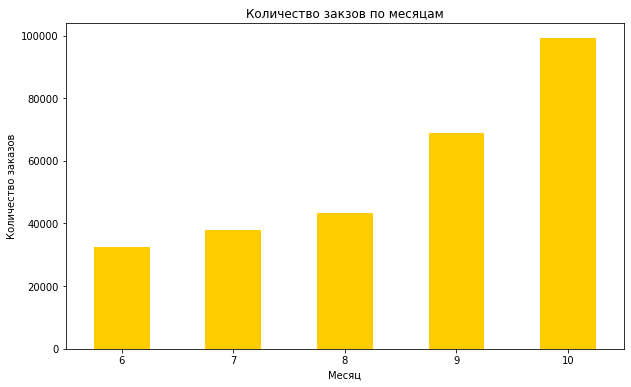

None

,order_id
month,
6,32461
7,37933
8,43197
9,68961
10,99152


In [36]:
orders_per_month = df_new_col.groupby('month').agg({'order_id':'count'})

orders_per_month.plot(kind = 'bar', figsize = (10,6), rot = 360, legend = False, color = '#FFCC00')

plt.xlabel('Месяц')
plt.title('Количество закзов по месяцам')
plt.ylabel('Количество заказов')


display(plt.show())
orders_per_month




На графике видим, что количество заказов растет от июня к октябрю примерно в три раза: с 32461 заказов в июне до 99152 заказов в октябре. Темпы роста увеличиваются с начала сентября.

#### Распределение заказов по типу мероприятия, типу устройства и возрастному рейтингу в зависимости от сезона

##### Типы мероприятий по сезонам

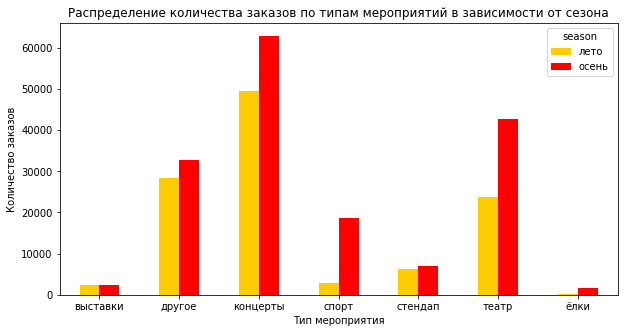

In [37]:
grouped_by_type_season = df_new_col.groupby('event_type_main')['season'].value_counts().unstack(fill_value = 0)

grouped_by_type_season.plot(kind = 'bar', title = 'Распределение количества заказов по типам мероприятий в зависимости от сезона',
             legend = True,  xlabel = 'Тип мероприятия', ylabel = 'Количество заказов',
             figsize = (10,5), color = ('#FFCC00','#FF0000'), rot = 0)



plt.show()

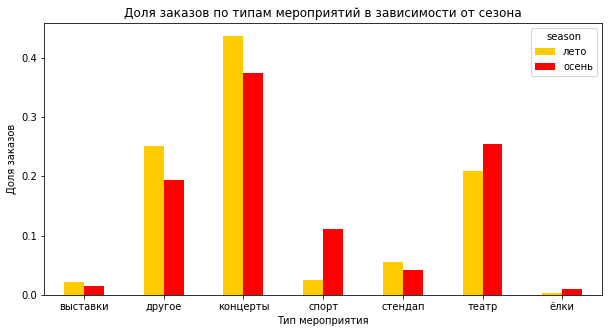

In [38]:
grouped_by_type = df_new_col.groupby(['event_type_main','season'], as_index = False)['order_id'].count()

for i in range(len(grouped_by_type)):
    if grouped_by_type.loc[i,'season'] == 'лето':
        grouped_by_type.loc[i,'share_for_season'] = grouped_by_type.loc[i,'order_id'] / grouped_by_type[grouped_by_type['season'] == 'лето']['order_id'].sum()
    elif grouped_by_type.loc[i,'season'] == 'осень':
        grouped_by_type.loc[i,'share_for_season'] = grouped_by_type.loc[i,'order_id'] / grouped_by_type[grouped_by_type['season'] == 'осень']['order_id'].sum()
    else:
        pass
      
grouped_by_type_plot = grouped_by_type.groupby(['event_type_main','season'])['share_for_season'].min().unstack(fill_value = 0)
grouped_by_type_plot.plot(kind = 'bar', title = 'Доля заказов по типам мероприятий в зависимости от сезона',
             legend = True,  xlabel = 'Тип мероприятия', ylabel = 'Доля заказов',
             figsize = (10,5), color = ('#FFCC00','#FF0000'), rot = 0)



plt.show()



На диаграмме видим, что осенью относительно лета увеличилась доля категорий Спорт и Театр. У остальных категорий наблюдается незначтельное снижение доли (за счет перераспределения). Учитывая общий рост количеста заказов за осенний период по сравнению с летним и обращаясь к диаграмме с абсолютным количеством заказов по категориям в разрезе сезонов, можно предположить, что по всем категориям наблюдается рост абсолютного количества заказов, при этом за счет более значительного роста для Театра и Спорта их доля увеличивается.

##### Типы устройств по сезонам

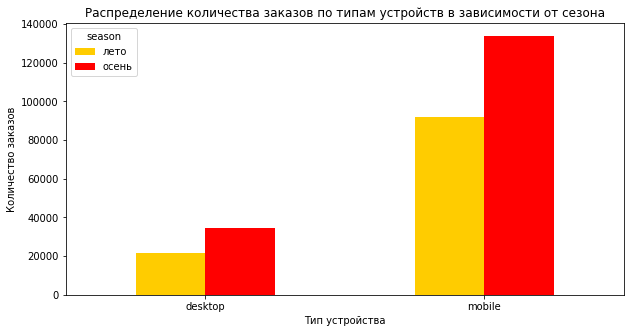

In [39]:
grouped_by_devices_season = df_new_col.groupby('device_type_canonical')['season'].value_counts().unstack(fill_value = 0)

grouped_by_devices_season.plot(kind = 'bar', title = 'Распределение количества заказов по типам устройств в зависимости от сезона',
             legend = True,  xlabel = 'Тип устройства', ylabel = 'Количество заказов',
             figsize = (10,5), color = ('#FFCC00','#FF0000'), rot = 0)



plt.show()

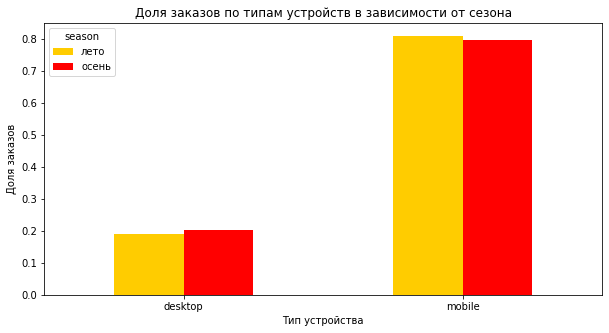

In [40]:
grouped_by_devices = df_new_col.groupby(['device_type_canonical','season'], as_index = False)['order_id'].count()

for i in range(len(grouped_by_devices)):
    if grouped_by_devices.loc[i,'season'] == 'лето':
        grouped_by_devices.loc[i,'share_for_season'] = grouped_by_devices.loc[i,'order_id'] / grouped_by_devices[grouped_by_devices['season'] == 'лето']['order_id'].sum()
    elif grouped_by_devices.loc[i,'season'] == 'осень':
        grouped_by_devices.loc[i,'share_for_season'] = grouped_by_devices.loc[i,'order_id'] / grouped_by_devices[grouped_by_devices['season'] == 'осень']['order_id'].sum()
    else:
        pass
    
grouped_by_devices_plot = grouped_by_devices.groupby(['device_type_canonical','season'])['share_for_season'].min().unstack(fill_value = 0)
grouped_by_devices_plot.plot(kind = 'bar', title = 'Доля заказов по типам устройств в зависимости от сезона',
             legend = True,  xlabel = 'Тип устройства', ylabel = 'Доля заказов',
             figsize = (10,5), color = ('#FFCC00','#FF0000'), rot = 0)



plt.show()   

На графике заметно незначительное увеличение доли заказов с устройств десктоп осенью относительно лета. Это объясняется тем, что пользователи летом чаще находятся в поездках и с большей вероятностью совершают покупки с мобильных устройств. Однако изменение незначительное.

##### Возрастной рейтинг по сезонам

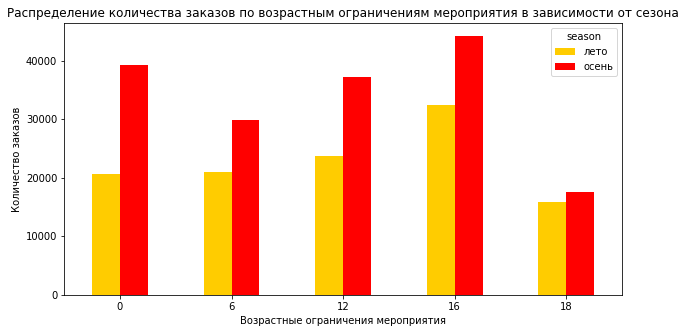

In [41]:
grouped_by_age_limit_season = df_new_col.groupby('age_limit')['season'].value_counts().unstack(fill_value = 0)

grouped_by_age_limit_season.plot(kind = 'bar', title = 'Распределение количества заказов по возрастным ограничениям мероприятия в зависимости от сезона',
             legend = True,  xlabel = 'Возрастные ограничения мероприятия', ylabel = 'Количество заказов',
             figsize = (10,5), color = ('#FFCC00','#FF0000'), rot = 0)



plt.show()

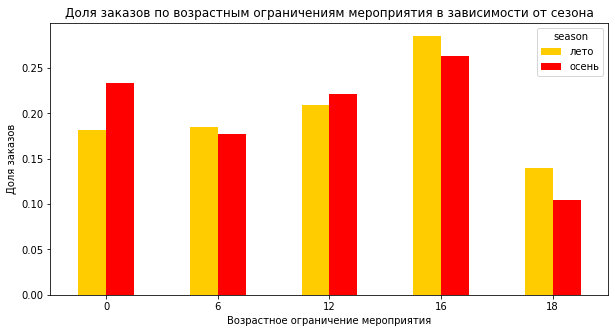

In [42]:
grouped_by_age_limit = df_new_col.groupby(['age_limit','season'], as_index = False)['order_id'].count()

for i in range(len(grouped_by_age_limit)):
    if grouped_by_age_limit.loc[i,'season'] == 'лето':
        grouped_by_age_limit.loc[i,'share_for_season'] = grouped_by_age_limit.loc[i,'order_id'] / grouped_by_age_limit[grouped_by_age_limit['season'] == 'лето']['order_id'].sum()
    elif grouped_by_age_limit.loc[i,'season'] == 'осень':
        grouped_by_age_limit.loc[i,'share_for_season'] = grouped_by_age_limit.loc[i,'order_id'] / grouped_by_age_limit[grouped_by_age_limit['season'] == 'осень']['order_id'].sum()
    else:
        pass
    
grouped_by_age_limit_plot = grouped_by_age_limit.groupby(['age_limit','season'])['share_for_season'].min().unstack(fill_value = 0)
grouped_by_age_limit_plot.plot(kind = 'bar', title = 'Доля заказов по возрастным ограничениям мероприятия в зависимости от сезона',
             legend = True,  xlabel = 'Возрастное ограничение мероприятия', ylabel = 'Доля заказов',
             figsize = (10,5), color = ('#FFCC00','#FF0000'), rot = 0)



plt.show()  

С наступлением осени увеличивается доля мероприятий с возрастный ограничением 0+ и 12+, а доля мероприятий 18+ и 16+ снижается. предполагаю, что это связано с открытием театрального сезона - большое количество театров выпускают детские спектакли.

#### Изменение выручки с продажи одного билета в зависимости от типа мероприятия летом и осенью

In [43]:
rev_per_ticket = df_new_col.groupby(['event_type_main','season'], as_index = False)['one_ticket_revenue_rub'].mean()

rev_per_ticket

,event_type_main,season,one_ticket_revenue_rub
0,выставки,лето,86.744476
1,выставки,осень,91.905093
2,другое,лето,88.021277
3,другое,осень,77.414270
4,концерты,лето,305.004548
5,концерты,осень,269.376312
6,спорт,лето,55.247119
7,спорт,осень,50.245481
8,стендап,лето,218.585827
9,стендап,осень,231.466954


/tmp/ipykernel_31/369318229.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_new_col['season'] = df_new_col['season'].astype('str')


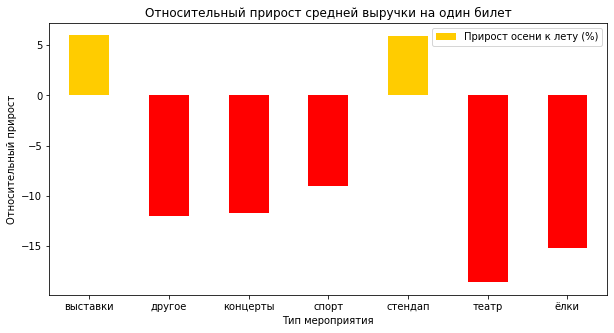

In [44]:
df_new_col['season'] = df_new_col['season'].astype('str')

rev_per_ticket_by_cat = df_new_col.groupby(['event_type_main','season'])['one_ticket_revenue_rub'].mean().unstack()
rev_per_ticket_by_cat['Прирост осени к лету (%)'] = round((rev_per_ticket_by_cat['осень'] - rev_per_ticket_by_cat['лето']) / rev_per_ticket_by_cat['лето'] * 100 , 2)
rev_per_ticket_by_cat['Прирост осени к лету (%)'].plot(kind = 'bar', title = 'Относительный прирост средней выручки на один билет',
             legend = True,  xlabel = 'Тип мероприятия', ylabel = 'Относительный прирост',
             figsize = (10,5), rot = 0, color = [*['#FFCC00']*1, *['#FF0000']*3,*['#FFCC00']*1,*['#FF0000']*2 ])


plt.show()  

На диаграмме заметно, что по основной массе типов событий средняя выручка от одного билета осенью снизиласьпричем значительно: от 5% для спортивных мероприятий до 18% для театра. Возможно, это вопрос условий сотрудничества с партнерами.

При этом по категориям стендап и выставки средняя выручка с одного билета увеличилась на 6%.

**Вывод**
Осенью относительно лета увеличилась доля категорий Спорт и Театр. У остальных категорий наблюдается незначительное снижение доли при росте абсолютных значений количества заказов. По всем категориям наблюдается рост абсолютного количества заказов,  за счет более быстрого роста для Театра и Спорта их доля увеличивается.

Заметно небольшое увеличение доли заказов с устройств десктоп осенью относительно лета. Это объясняется тем, что пользователи летом чаще находятся в поездках и с большей вероятностью совершают покупки с мобильных устройств. Однако изменение незначительное и основная тенденция - около 80% заказов с мобильных устройств - не подвержена сезонности.

С наступлением осени увеличивается доля мероприятий с возрастный ограничением 0+ и 12+, а доля мероприятий 18+ и 16+ снижается. Вероятно, это связано с открытием театрального сезона и быстрым ростом количества заказов на спортивные события - большое количество театров выпускают детские спектакли, а большиство спортивных мероприятий не имеют ограничений по возрасту.

По основной массе типов событий средняя выручка от одного билета осенью снизилась причем значительно: от 5% для спортивных мероприятий до 18% для театра. Необходимо уточнить у коллег, не является ли такое изменений результатом изменения условий сотрудничества с партнерами, проверить, снизилась ли доля выручки от общей суммы заказов или общая сумма заказа тоже снижается. 

При этом по категориям стендап и выставки средняя выручка с одного билета увеличилась на 6%.

#### Осенняя активность пользователей
Дополнительно рассмотри активность пользователей в период с 2024-09-01 по 2024-10-31:
1. Проанализируем динамику изменений по дням для:
* общего числа заказов;
* количества активных пользователей DAU;
* среднего числа заказов на одного пользователя;
* средней стоимости одного билета.

2. Изучим недельную цикличность в поведении пользователей.

##### Динамика изменений по дням


In [45]:
fall_df = df_new_col[df_new_col['season'] == 'осень']


per_day = fall_df.groupby('date', as_index = False).agg({'order_id':'count','user_id':'nunique','total':'sum','tickets_count':'sum'})

per_day = per_day.rename(columns={'order_id':'orders_count','user_id':'dau'})

per_day['orders_per_user'] = per_day['orders_count'] / per_day['dau']

per_day['avg_ticket_cost'] = per_day['total'] / per_day['tickets_count']

per_day.tail(35)

,date,orders_count,dau,total,tickets_count,orders_per_user,avg_ticket_cost
26,2024-09-27,2758,1018,1.728360e+07,7373.0,2.709234,2344.174295
27,2024-09-28,2508,925,1.606708e+07,7061.0,2.711351,2275.468520
28,2024-09-29,2203,842,1.402775e+07,5955.0,2.616390,2355.625036
29,2024-09-30,2313,883,1.426189e+07,6276.0,2.619479,2272.449218
30,2024-10-01,7295,1098,3.087549e+07,21831.0,6.643898,1414.295707
31,2024-10-02,2568,916,1.591225e+07,6987.0,2.803493,2277.407421
32,2024-10-03,2644,950,1.714276e+07,7194.0,2.783158,2382.924622
33,2024-10-04,2940,967,1.880412e+07,8205.0,3.040331,2291.787577
34,2024-10-05,2706,981,1.825003e+07,7635.0,2.758410,2390.311995
35,2024-10-06,2431,889,1.641679e+07,6877.0,2.734533,2387.202667


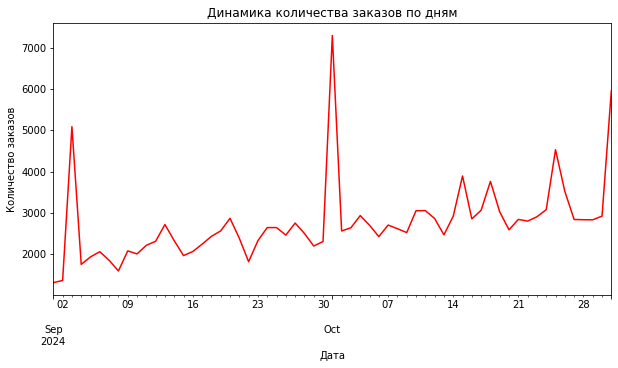

In [46]:
per_day.plot(kind = 'line', x = 'date', y = 'orders_count', figsize = (10,5), color = '#FF0000', legend = False)

plt.xlabel('Дата')
plt.ylabel('Количество заказов')
plt.title('Динамика количества заказов по дням')

plt.show()

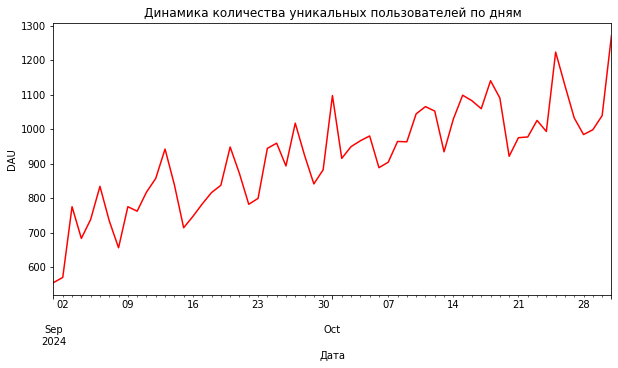

In [47]:
per_day.plot(kind = 'line', x = 'date', y = 'dau', figsize = (10,5), color = '#FF0000', legend = False)

plt.xlabel('Дата')
plt.ylabel('DAU')
plt.title('Динамика количества уникальных пользователей по дням')

plt.show()

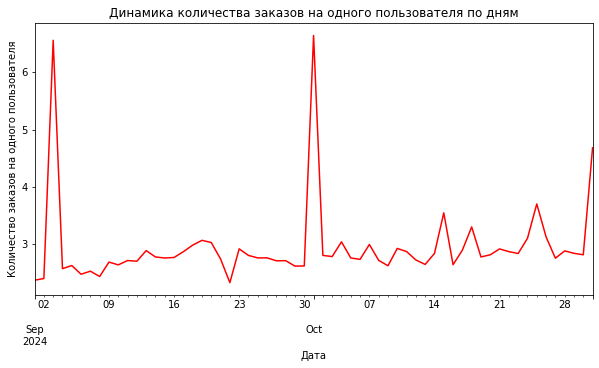

In [48]:
per_day.plot(kind = 'line', x = 'date', y = 'orders_per_user', figsize = (10,5), color = '#FF0000', legend = False)

plt.xlabel('Дата')
plt.ylabel('Количество заказов на одного пользователя')
plt.title('Динамика количества заказов на одного пользователя по дням')

plt.show()

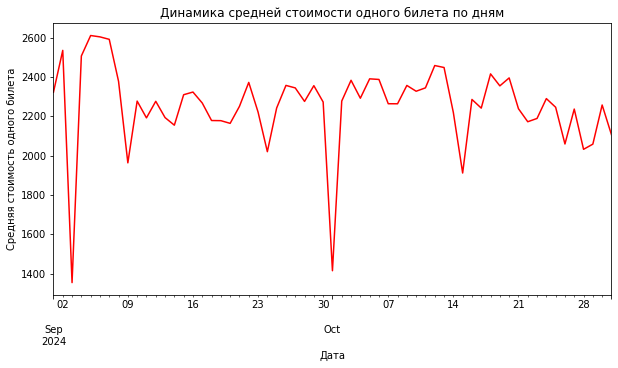

In [49]:
per_day.plot(kind = 'line', x = 'date', y = 'avg_ticket_cost', figsize = (10,5), color = '#FF0000', legend = False)

plt.xlabel('Дата')
plt.ylabel('Средняя стоимость одного билета')
plt.title('Динамика средней стоимости одного билета по дням')

plt.show()

Для динамики количества заказов в день характерен постепенный прирост на протяжении всего рассматриваемого периода с резкими пиками 3 сентября, 1 октября и 31 октября, причем, если обратить внимание на динамику DAU и количества заказов на одного пользователя - заметно, что количество заказов в эти пиковые дни растут именно за счет резкого увеличения количества заказов на одного пользователя, в то время как DAU показывает стабильный рост с перепадами. скорее всего являющимися недельной цикличностью. 

Средняя стоимость одного билета по дням демонстрирует очеь плавный рост с 9 сентября до 14 октября, затем есть тенденция к спаду. На этом графике видим отрицательные пики так же 3 сентября, 1 октября и 31 октября.

Резюмируя можно отметить три основных момента:
1. Общая тенденция к увеличению количества заказов, DAU и плавный рост количества заказов на одного пользователя. 
2. Меняющийся вектор динамики средней стоимости одного билета: снижение в период с 1 по 9 сентября, медленный рост с 10 сентября до 14 октября, и вновь снижение с 15 октября. Рекомендую провести дополнительный анализ: рассмотреть динамику стоимости одного билета по дням в разрезе типов мероприятий, возможно, удастся выделить конкретные мероприятия, которые за счет большого количества билетов могут менять тенденцию на небольшой период.
3. 3 сентября, 1 октября и 31 октября дни аномального спроса, характеризующиеся большим количеством заказов при относительно стабильном количестве уникальных пользователей и резком уменьшении средне стоимости билета. Необходимо уточнить у команды продукта, были ли в эти дни маркетинговые или партнерские активности, могущие оказать такое влияние. Можно рассмотреть эту ситуацию более подробно в разрезе конкретных пользователей: если у единичных пользователей в эти дни было нереалистично большое количество заказов с низкой средней стоимостью билета - возможно речь идет о тезнической ошибке.

##### Недельная цикличность

In [50]:
fall_df['dow'] = fall_df['date'].dt.day_of_week
fall_df['weekday'] = pd.cut(fall_df['dow'], bins = [-1,4,6], labels = ['будни','выходные'])
fall_df.head()

/tmp/ipykernel_31/2806184021.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fall_df['dow'] = fall_df['date'].dt.day_of_week
/tmp/ipykernel_31/2806184021.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fall_df['weekday'] = pd.cut(fall_df['dow'], bins = [-1,4,6], labels = ['будни','выходные'])


,order_id,user_id,date,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,...,city_id,venue_id,venue_name,venue_address,revenue_rub,one_ticket_revenue_rub,month,season,dow,weekday
2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,нет,0,rub,mobile,1258.57,...,213.0,4507.0,"Училище искусств ""Нирвана"" Инк","алл. Юбилейная, д. 5/6",1258.57,314.642500,10,осень,6,выходные
4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,нет,18,rub,mobile,1390.41,...,240.0,1896.0,"Театр кукол ""Огни"" Инкорпорэйтед","ш. Набережное, д. 595 стр. 8",1390.41,463.470000,10,осень,4,будни
5,2613713,000898990054619,2024-10-23,2024-10-23 15:12:00,500862,нет,12,rub,mobile,902.74,...,193.0,930.0,"Школа живописи ""Солнце"" Групп","бул. Отрадный, д. 4 стр. 1",902.74,300.913333,10,осень,2,будни
7,4657981,000a55a418c128c,2024-09-29,2024-09-29 19:39:12,265857,нет,12,rub,mobile,47.78,...,18.0,3159.0,"Клуб начинающих писателей ""Таблицы"" Групп","ул. О.Кошевого, д. 7",47.78,47.780000,9,осень,6,выходные
8,4657952,000a55a418c128c,2024-10-15,2024-10-15 10:29:04,271579,нет,12,rub,mobile,74.84,...,18.0,3159.0,"Клуб начинающих писателей ""Таблицы"" Групп","ул. О.Кошевого, д. 7",74.84,37.420000,10,осень,1,будни


In [51]:
weekday_weekend = fall_df.groupby('weekday', as_index = False).agg({'date':'nunique', 'order_id':'count','user_id':'nunique','total':'sum','tickets_count':'sum'})
weekday_weekend = weekday_weekend.rename(columns = {'date':'days_count','order_id':'total_orders'})

weekday_weekend['avg_orders_count'] = weekday_weekend['total_orders'] / weekday_weekend['days_count']

weekday_weekend['avg_ticket_cost'] = weekday_weekend['total'] / weekday_weekend['tickets_count']

weekday_weekend['avg_orders_per_user'] = weekday_weekend['total_orders'] / weekday_weekend['user_id']

weekday_weekend['avg_orders_cost'] = weekday_weekend['total'] / weekday_weekend['total_orders']

weekday_weekend

,weekday,days_count,total_orders,user_id,total,tickets_count,avg_orders_count,avg_ticket_cost,avg_orders_per_user,avg_orders_cost
0,будни,44,127636,13199,7.544623e+08,350363.0,2900.818182,2153.373194,9.670127,5911.046195
1,выходные,17,40477,7086,2.606368e+08,111982.0,2381.000000,2327.488331,5.712250,6439.133293


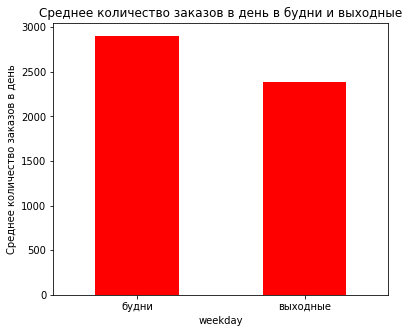

In [52]:
weekday_weekend_orders = weekday_weekend[['weekday','avg_orders_count']].set_index('weekday')

weekday_weekend_orders.plot(kind = 'bar', figsize = (6,5), legend = False, color = '#FF0000', rot = 360)


plt.ylabel('Среднее количество заказов в день')
plt.title('Среднее количество заказов в день в будни и выходные')

plt.show()

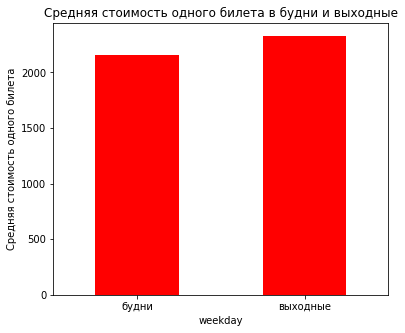

In [53]:
weekday_weekend_tcost = weekday_weekend[['weekday','avg_ticket_cost']].set_index('weekday')

weekday_weekend_tcost.plot(kind = 'bar', figsize = (6,5), legend = False, color = '#FF0000', rot = 360)


plt.ylabel('Средняя стоимость одного билета')
plt.title('Средняя стоимость одного билета в будни и выходные')

plt.show()

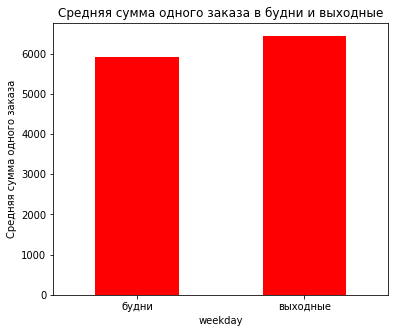

In [54]:
weekday_weekend_ocost = weekday_weekend[['weekday','avg_orders_cost']].set_index('weekday')

weekday_weekend_ocost.plot(kind = 'bar', figsize = (6,5), legend = False, color = '#FF0000', rot = 360)


plt.ylabel('Средняя сумма одного заказа')
plt.title('Средняя сумма одного заказа в будни и выходные')

plt.show()

В будни в среднем оформляется больше заказов, чем в выходные: 2901 и 2381 соответственно. Однако необходимо учитывать, что у нас есть три пиковых дня (3 сентября, 1 октября и 31 октября) и все они будние, до уточнения обстоятельств аномального спроса в эти дни рано делать выводы о соотношении среднего количества заказов в будни и выходные. То же самое можно сказать о соотношении средней суммы одного заказа и средней стоимости одного билета для будней и выходных: сейчас в будни показатели стоимости немного ниже. Рекомендую, помимо уточнения обстоятельств пиковых дней рассмотреть отдельно статистику по будням/выходным без их учета.



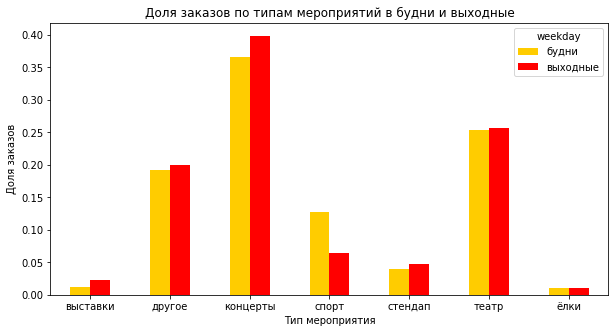

In [55]:
grouped_by_type_weekday = fall_df.groupby(['event_type_main','weekday'], as_index = False)['order_id'].count()

for i in range(len(grouped_by_type_weekday)):
    if grouped_by_type_weekday.loc[i,'weekday'] == 'будни':
        grouped_by_type_weekday.loc[i,'share_for_weekday'] = grouped_by_type_weekday.loc[i,'order_id'] / grouped_by_type_weekday[grouped_by_type_weekday['weekday'] == 'будни']['order_id'].sum()
    elif grouped_by_type_weekday.loc[i,'weekday'] == 'выходные':
        grouped_by_type_weekday.loc[i,'share_for_weekday'] = grouped_by_type_weekday.loc[i,'order_id'] / grouped_by_type_weekday[grouped_by_type_weekday['weekday'] == 'выходные']['order_id'].sum()
    else:
        pass
 
grouped_by_type_weekday_plot = grouped_by_type_weekday.groupby(['event_type_main','weekday'])['share_for_weekday'].min().unstack(fill_value = 0)
grouped_by_type_weekday_plot.plot(kind = 'bar', title = 'Доля заказов по типам мероприятий в будни и выходные',
             legend = True,  xlabel = 'Тип мероприятия', ylabel = 'Доля заказов',
             figsize = (10,5), color = ('#FFCC00','#FF0000'), rot = 0)



plt.show()



В будни относительно чаще покупают билеты на спортивные мероприятия, в выходные есть перевес у концертов и выставок, в остальном раздичия покупательского интереса в размерезе типов мероприятий в будни и выходные несущественны. Можно предположить, что покупки билетов на спортивные мероприятия могут быть рабочей задачей для неких организоторов.

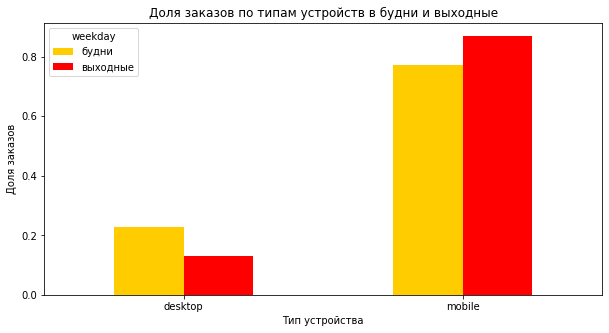

In [56]:
grouped_by_devices_weekday = fall_df.groupby(['device_type_canonical','weekday'], as_index = False)['order_id'].count()

for i in range(len(grouped_by_devices_weekday)):
    if grouped_by_devices_weekday.loc[i,'weekday'] == 'будни':
        grouped_by_devices_weekday.loc[i,'share_for_weekday'] = grouped_by_devices_weekday.loc[i,'order_id'] / grouped_by_devices_weekday[grouped_by_devices_weekday['weekday'] == 'будни']['order_id'].sum()
    elif grouped_by_devices_weekday.loc[i,'weekday'] == 'выходные':
        grouped_by_devices_weekday.loc[i,'share_for_weekday'] = grouped_by_devices_weekday.loc[i,'order_id'] / grouped_by_devices_weekday[grouped_by_devices_weekday['weekday'] == 'выходные']['order_id'].sum()
    else:
        pass
    
grouped_by_devices_weekday_plot = grouped_by_devices_weekday.groupby(['device_type_canonical','weekday'])['share_for_weekday'].min().unstack(fill_value = 0)
grouped_by_devices_weekday_plot.plot(kind = 'bar', title = 'Доля заказов по типам устройств в будни и выходные',
             legend = True,  xlabel = 'Тип устройства', ylabel = 'Доля заказов',
             figsize = (10,5), color = ('#FFCC00','#FF0000'), rot = 0)



plt.show()

Предсказуемо чаще в выходные совершают покупки с мобильных устройств. 

**Вывод об особенностях пользовательского поведения осенью**
1. Наблюдается общая тенденция к увеличению количества заказов, DAU и плавный рост количества заказов на одного пользователя. 
2. Виден меняющийся вектор динамики средней стоимости одного билета: снижение в период с 1 по 9 сентября, медленный рост с 10 сентября до 14 октября, и вновь снижение с 15 октября. Рекомендую провести дополнительный анализ: рассмотреть динамику стоимости одного билета по дням в разрезе типов мероприятий, возможно, удастся выделить конкретные мероприятия, которые за счет большого количества билетов могут менять тенденцию на небольшой период.
3. 3 сентября, 1 октября и 31 октября дни аномального спроса, характеризующиеся большим количеством заказов при относительно стабильном количестве уникальных пользователей и резком уменьшении средне стоимости билета. Необходимо уточнить у команды продукта, были ли в эти дни маркетинговые или партнерские активности, могущие оказать такое влияние. Можно рассмотреть эту ситуацию более подробно в разрезе конкретных пользователей: если у единичных пользователей в эти дни было нереалистично большое количество заказов с низкой средней стоимостью билета - возможно речь идет о технической ошибке.
Все три пиковых дня будние, до уточнения обстоятельств аномального спроса в эти дни преждевременно делать выводы о соотношении среднего количества заказов в будни и выходные и наличии недельной цикличности спроса. То же самое можно сказать о соотношении средней суммы одного заказа и средней стоимости одного билета для будней и выходных: сейчас в будни показатели стоимости немного ниже. Рекомендую, помимо уточнения обстоятельств пиковых дней рассмотреть отдельно статистику по будням/выходным без их учета.
4. В будни относительно чаще покупают билеты на спортивные мероприятия, в выходные есть перевес у концертов и выставок, в остальном раздичия покупательского интереса в размерезе типов мероприятий в будни и выходные несущественны. Можно предположить, что покупки билетов на спортивные мероприятия могут быть рабочей задачей для неких организоторов.
5. В рабочие дни чаще покупки совершают с десктоп устройст - это общая тенденция использования интернета, т.к. большая часть пользователей в будни находится у рабочих компьютеров.

### Популярные события и партнеры


In [57]:
grouped_by_region = df_new_col.groupby('region_name', as_index = False).agg({'event_id':'nunique','order_id':'count'})

grouped_by_region['share_of_orders%'] = round(grouped_by_region['order_id'] / df_new_col.shape[0] *100,2)

grouped_by_region['share_of_events%'] = round(grouped_by_region['event_id'] / df_new_col['event_id'].nunique() *100,2)

grouped_by_region.sort_values(by = 'order_id', ascending = False)

,region_name,event_id,order_id,share_of_orders%,share_of_events%
23,Каменевский регион,5797,85479,30.34,26.32
60,Североярская область,3777,43603,15.48,17.15
77,Широковская область,1217,16090,5.71,5.52
42,Медовская область,462,13585,4.82,2.10
45,Озернинский край,349,10405,3.69,1.58
...,...,...,...,...,...
33,Лесноярский край,2,19,0.01,0.01
32,Крутоводский регион,7,18,0.01,0.03
5,Верхозёрский край,2,11,0.00,0.01
66,Сосноводолинская область,2,10,0.00,0.01


In [58]:
region_top_by_orders = grouped_by_region.sort_values(by = 'order_id', ascending = False)[['region_name','order_id']].set_index('region_name')
region_top_by_orders.head(15)

,order_id
region_name,
Каменевский регион,85479
Североярская область,43603
Широковская область,16090
Медовская область,13585
Озернинский край,10405
Светополянский округ,7482
Малиновоярский округ,6509
Речиновская область,6266
Солнечноземская область,6239


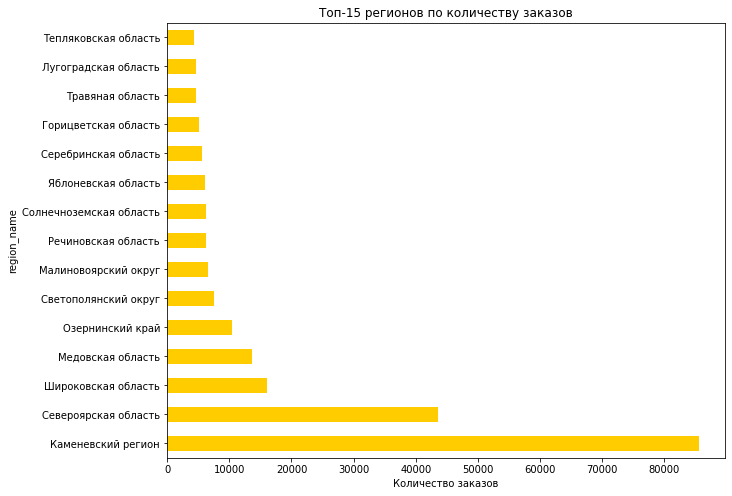

In [59]:
region_top_by_orders.head(15).plot(kind = 'barh', figsize = (10,8), legend = False, color = '#FFCC00', rot = 360)

plt.xlabel('Количество заказов')
plt.title('Топ-15 регионов по количеству заказов')

plt.show()

In [60]:
region_top_by_events = grouped_by_region.sort_values(by = 'event_id', ascending = False)[['region_name','event_id']].set_index('region_name')
region_top_by_events.head(15)

,event_id
region_name,
Каменевский регион,5797
Североярская область,3777
Широковская область,1217
Светополянский округ,1065
Речиновская область,701
Травяная область,667
Горицветская область,551
Серебринская область,541
Яблоневская область,534


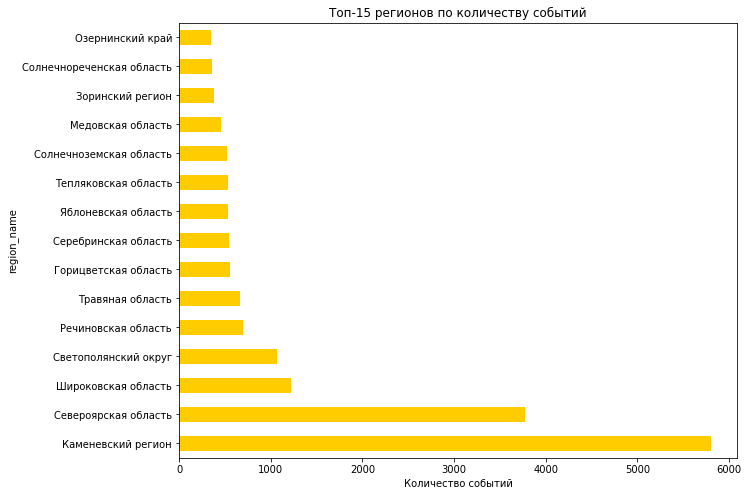

In [61]:
region_top_by_events.head(15).plot(kind = 'barh', figsize = (10,8), legend = False, color = '#FFCC00', rot = 360)

plt.xlabel('Количество событий')
plt.title('Топ-15 регионов по количеству событий')

plt.show()

По количеству уникальных мероприятий и по количеству оформленных заказов лидируют три региона:
1. Каменевский регион
2. Североярская область
3. Широковская область

Причем первые два региона показывают значительный отрыв от средних показателей по другим регионам: 5797 и 3777 уникальных мероприятий (что составляет 30.34% и 15,5% от общего количества уникальных мероприятий), а уже у Широковской области - 1217 мероприятий (5,7% от общего количества уникальных мероприятий), почти в три раза меньше, чем у Североярской области.

Похожая ситуация с количеством оформленных заказов: у Каменевского региона 85479 (26.32%), У Североярской области 43603 (17.15%), а у Широковской области уже 16090 (5.5%)).

Рекомендую сверить имеющиеся данные с двумя дополнительными разрезами: количество населания по регионам и количество реально проводимых мероприятий по регионам, чтобы определить точки роста во взаимодействии с партнерами и в вовлечении населения регионов в использование сервиса.


In [62]:
grouped_by_service = df_new_col.groupby('service_name', as_index = False).agg({'event_id':'nunique','order_id':'count'})

grouped_by_service['share_of_orders%'] = round(grouped_by_service['order_id'] / df_new_col.shape[0] *100,2)

grouped_by_service['share_of_events%'] = round(grouped_by_service['event_id'] / df_new_col['event_id'].nunique() *100,2)

grouped_by_service

,service_name,event_id,order_id,share_of_orders%,share_of_events%
0,Crazy ticket!,256,789,0.28,1.16
1,Show_ticket,295,2091,0.74,1.34
2,Билет по телефону,20,85,0.03,0.09
3,Билеты без проблем,4020,58065,20.61,18.25
4,Билеты в интернете,1,4,0.00,0.00
5,Билеты в руки,3492,39825,14.14,15.85
6,Быстробилет,255,1982,0.70,1.16
7,Быстрый кассир,20,379,0.13,0.09
8,Весь в билетах,856,16437,5.83,3.89
9,Восьмёрка,143,1106,0.39,0.65


In [63]:
service_top_by_orders = grouped_by_service.sort_values(by = 'order_id', ascending = False)[['service_name','order_id']].set_index('service_name')

service_top_by_orders.head(15)

,order_id
service_name,
Билеты без проблем,58065
Лови билет!,40545
Билеты в руки,39825
Мой билет,33948
Облачко,26410
Лучшие билеты,17619
Весь в билетах,16437
Прачечная,10222
Край билетов,6118


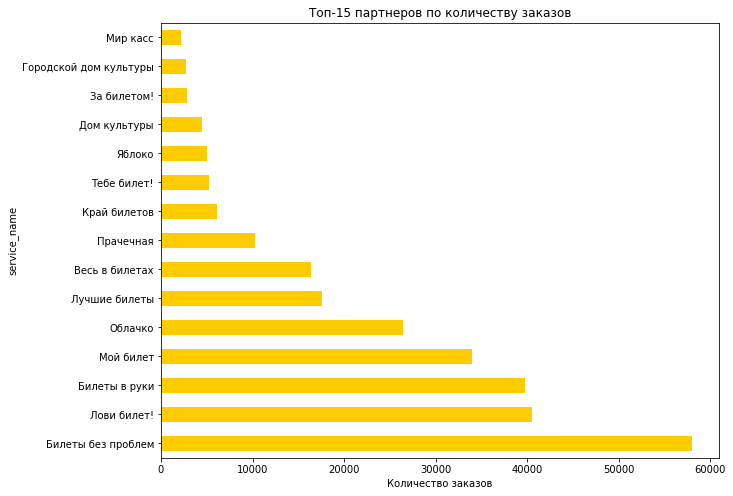

In [64]:
service_top_by_orders.head(15).plot(kind = 'barh', figsize = (10,8), legend = False, color = '#FFCC00', rot = 360)

plt.xlabel('Количество заказов')
plt.title('Топ-15 партнеров по количеству заказов')

plt.show()

In [65]:
service_top_by_events = grouped_by_service.sort_values(by = 'event_id', ascending = False)[['service_name','event_id']].set_index('service_name')
service_top_by_events.head(15)

,event_id
service_name,
Лови билет!,4824
Билеты без проблем,4020
Билеты в руки,3492
Облачко,2335
Лучшие билеты,1741
Мой билет,1298
Тебе билет!,1061
Прачечная,1026
Весь в билетах,856


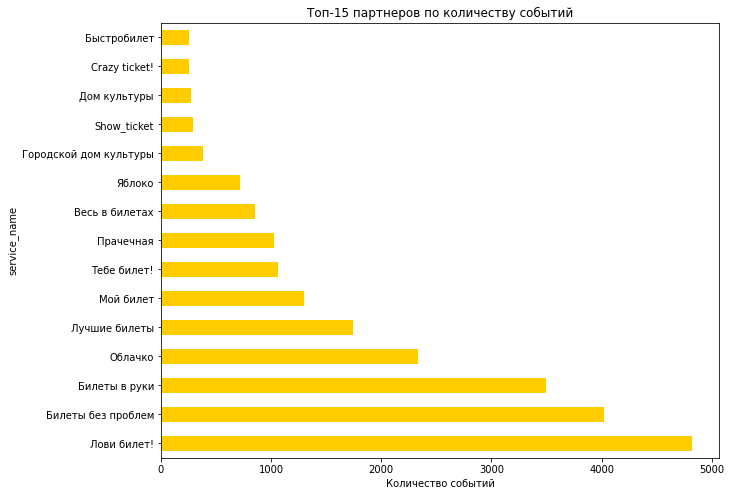

In [66]:
service_top_by_events.head(15).plot(kind = 'barh', figsize = (10,8), legend = False, color = '#FFCC00', rot = 360)

plt.xlabel('Количество событий')
plt.title('Топ-15 партнеров по количеству событий')

plt.show()

Среди партнеров явным лидером по количеству обработанных заказов является Билеты без проблем - 58065 заказов, что составляет 20.6% от общего количества заказов. Следующие за ним в рейтинге Лови билет! с 40545 заказов и Билет в руки с 39825 заказов составили 14.4% и 14.14% процентов от общего количества обработнных заказов соответственно.

По количеству уникальных событий видим другое распределение среди этой же тройки партнеров. Лидером является Лови билет! с 4824 уникальных событий, что составляет 21.9% от общего количества событий. Второе место у Билеты без проблем: 4020 событий в абсолютных значениях и 18.25% в относительных. На третьем месте Билеты в руки: 3492 событий и 15.85%. Такая разница в рейтингах вызвана тем, что у Лови билет есть ряд событий, на которые было оформлено мало заказов.

**Вывод**

Регионы-лидеры:

1. Каменевский регион
2. Североярская область
3. Широковская область

Рекомендую сверить имеющиеся данные с двумя дополнительными разрезами: количество населания по регионам и количество реально проводимых мероприятий по регионам, чтобы определить точки роста во взаимодействии с партнерами и в вовлечении населения регионов в использование сервиса.

Партнеры-лидеры:

1. Билеты без проблем
2. Лови билет!
3. Билет в руки

Рекомендую дополнительно рассмотреть состав событий у партнера Лови билет! чтобы определить причину второго места по количеству заказов при значительном перевесе по количеству событий.

## Статистический анализ данных

Проверим две гипотезы, которые предполагают большую активность пользователей мобильных устройств:

* Среднее количество заказов на одного пользователя мобильного приложения выше по сравнению с пользователями стационарных устройств

Группа А - desktop, группы B - mobile.

H0: Среднее количество заказов на одного пользователя в группах A и B не отличается, т.е. μA = μB

H1 (односторонняя): Среднее количество заказов на одного пользователя в группе B будет выше, чем в группе A, т.е. μA < μB 


* Среднее время между заказами пользователей мобильных приложений выше по сравнению с пользователями стационарных устройств

Группа А - desktop, группы B - mobile.

H0: Среднее время между заказами пользователей в группах A и B не отличается, т.е. μA = μB

H1 (односторонняя): Среднее время между заказами пользователей в группе B будет выше, чем в группе A, т.е. μA < μB 



In [87]:
# подсчёт уникальный user_id по группам
fall_df.groupby('device_type_canonical', as_index = False)[['user_id']].nunique()

,device_type_canonical,user_id
0,desktop,4868
1,mobile,14118


Количество пользователей по группе B превышает количество пользователей из группы A более чем в два раза. Предлагаю продолжать исследование.

Проверим, не попали ли пользователи в две группы одновременно.

In [88]:
# подсчёт уникальных групп на каждого пользователя
grouped_by_user = fall_df.groupby('user_id', as_index = False)['device_type_canonical'].nunique().sort_values(by = 'device_type_canonical', ascending = False)
grouped_by_user

,user_id,device_type_canonical
7874,7fdc728072cfb0a,2
4599,4a39882f55cb815,2
12085,c3bfc6d4b0cc207,2
4594,4a245632055e673,2
4591,4a179bd6f563e76,2
...,...,...
5856,5e737897694a065,1
5857,5e73d6b56b797e7,1
5858,5e7ded9a2c9d7a9,1
5859,5e7f6b576bf5225,1


In [104]:
intersection = grouped_by_user[grouped_by_user['device_type_canonical'] > 1]['user_id']
intersection_list = intersection.to_list()


df_compare = fall_df[~fall_df['user_id'].isin(intersection_list)]

df_compare.groupby('device_type_canonical', as_index = False)[['user_id']].nunique()

,device_type_canonical,user_id
0,desktop,1630
1,mobile,10880


После удаления пользователей, оформлявших заказы и с мобильных и с десктоп устройств различия в размере групп усилились. 

In [105]:
#считаем для каждого пользователя количество заказов

orders_per_user_devices = df_compare.groupby('user_id', as_index = False).agg({'order_id':'count','device_type_canonical':'min'})
orders_per_user_devices



,user_id,order_id,device_type_canonical
0,0005ca5e93f2cf4,1,mobile
1,000898990054619,2,mobile
2,000a55a418c128c,2,mobile
3,001e7037d013f0f,2,mobile
4,00245c702bc343e,2,mobile
...,...,...,...
12505,ffed3ff067d4f12,3,mobile
12506,fff13b79bd47d7c,3,mobile
12507,fff32fc9ad0f9f6,1,desktop
12508,fffeeb3c120cf0b,1,desktop


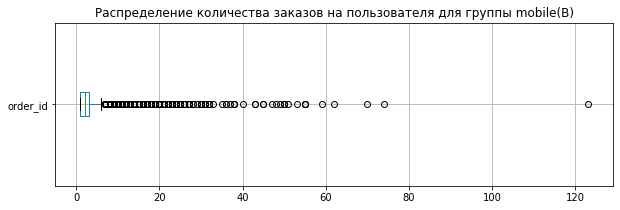

In [106]:
#Проверим данные по группам на наличие выбросов
orders_per_user_devices_mob = orders_per_user_devices[orders_per_user_devices['device_type_canonical'] == 'mobile']

orders_per_user_devices_mob.boxplot(vert = False, figsize = (10,3))

plt.title('Распределение количества заказов на пользователя для группы mobile(B)')

plt.show()


In [107]:
orders_per_user_devices_mob['order_id'].describe()

count    10880.000000
mean         2.868658
std          4.149820
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max        123.000000
Name: order_id, dtype: float64

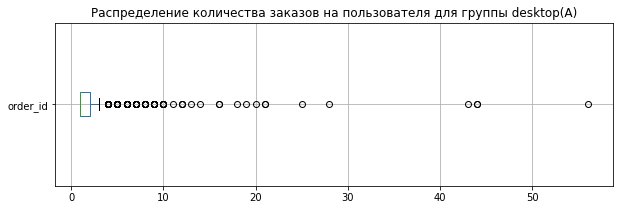

In [108]:
orders_per_user_devices_desk = orders_per_user_devices[orders_per_user_devices['device_type_canonical'] == 'desktop']

orders_per_user_devices_desk.boxplot(vert = False, figsize = (10,3))

plt.title('Распределение количества заказов на пользователя для группы desktop(A)')

plt.show()

In [109]:
orders_per_user_devices_desk['order_id'].describe()

count    1630.000000
mean        1.968098
std         3.049051
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max        56.000000
Name: order_id, dtype: float64

На диаграммах размаха и по разнице между средними значениями и медианами видим наличие выбросов и отличия в стандартных отклонениях, что говорит о неравенстве дисперсий. При наличии выбросов на больших выборках, независимых выборок и выбранной средней пользовательской метрики останавливаемся на t-тесте Уэлча для проверки первой гипотезы. 
Уровень статистической значимости устанавливаем на 5%

In [110]:
a = orders_per_user_devices_desk['order_id']
b = orders_per_user_devices_mob['order_id']

alpha = 0.05

stat_ttest, p_value_ttest = ttest_ind(a, b, alternative='less', equal_var=False)

if p_value_ttest > alpha:
    display(f'pvalue={p_value_ttest} > {alpha}')
    display('Нулевая гипотеза находит подтверждение! Среднее количество заказов на пользователя в группах A и B равны')
else:
    display(f'pvalue={p_value_ttest} < {alpha}')
    display('Нулевая гипотеза не находит подтверждения! Среднее количество заказов на пользователя в группе B выше, чем в группе А')



'pvalue=8.144468668144324e-26 < 0.05'

'Нулевая гипотеза не находит подтверждения! Среднее количество заказов на пользователя в группе B выше, чем в группе А'

Подтвердилась альтернативная гипотеза о том, что для пользователей мобильных устройств среднее количество заказов на пользователя выше, чем для пользователей стационарных компьютеров. Это объясняется тем, что пользователи, которые планируют совершать заказы часто скорее всего установят мобильное приложение, чтобы всегда иметь в доступе информацию о купленных билетах. Тогда как при редком использовании с мало знакомым интерфейсом удобнее работать с большого экрана.

In [111]:
#считаем для каждого пользователя среднее время между заказами

lag_between_orders_devices = df_compare.groupby('user_id', as_index = False).agg({'days_since_prev':'mean','device_type_canonical':'min'})
lag_between_orders_devices


,user_id,days_since_prev,device_type_canonical
0,0005ca5e93f2cf4,75.000000,mobile
1,000898990054619,51.000000,mobile
2,000a55a418c128c,16.000000,mobile
3,001e7037d013f0f,43.500000,mobile
4,00245c702bc343e,27.500000,mobile
...,...,...,...
12505,ffed3ff067d4f12,26.000000,mobile
12506,fff13b79bd47d7c,20.666667,mobile
12507,fff32fc9ad0f9f6,74.000000,desktop
12508,fffeeb3c120cf0b,NaN,desktop


In [112]:
#для пользователей, у которых был только олин заказ, посчитать метрику невозможно, удалим их из датасета

lag_between_orders_nonull = lag_between_orders_devices.dropna()
lag_between_orders_nonull

,user_id,days_since_prev,device_type_canonical
0,0005ca5e93f2cf4,75.000000,mobile
1,000898990054619,51.000000,mobile
2,000a55a418c128c,16.000000,mobile
3,001e7037d013f0f,43.500000,mobile
4,00245c702bc343e,27.500000,mobile
...,...,...,...
12503,ffe364dd8211157,41.333333,mobile
12504,ffe73c50cbd71fc,0.000000,mobile
12505,ffed3ff067d4f12,26.000000,mobile
12506,fff13b79bd47d7c,20.666667,mobile


In [113]:
lag_between_orders_nonull.groupby('device_type_canonical', as_index = False)[['user_id']].nunique()

,device_type_canonical,user_id
0,desktop,902
1,mobile,7032


В группе A осталось 902 пользователей, в группе B  7032


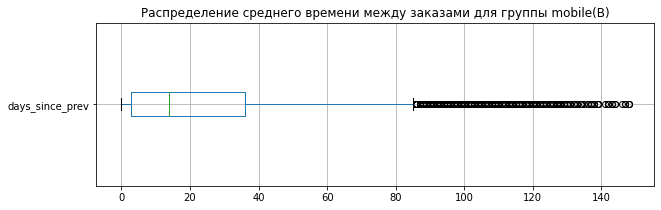

In [114]:
#Проверим данные по группам на наличие выбросов
lag_between_orders_mob = lag_between_orders_nonull[lag_between_orders_nonull['device_type_canonical'] == 'mobile']

lag_between_orders_mob.boxplot(vert = False, figsize = (10,3))

plt.title('Распределение среднего времени между заказами для группы mobile(B)')

plt.show()

In [115]:
lag_between_orders_mob['days_since_prev'].describe()

count    7032.000000
mean       25.192498
std        30.187846
min         0.000000
25%         2.851852
50%        14.000000
75%        36.000000
max       148.000000
Name: days_since_prev, dtype: float64

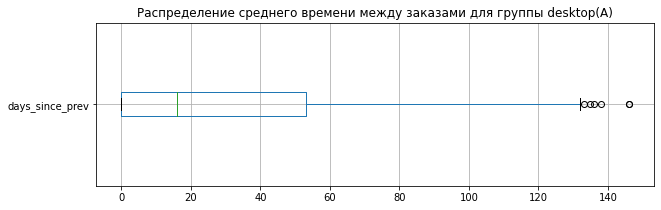

In [116]:
lag_between_orders_desk = lag_between_orders_nonull[lag_between_orders_nonull['device_type_canonical'] == 'desktop']

lag_between_orders_desk.boxplot(vert = False, figsize = (10,3))

plt.title('Распределение среднего времени между заказами для группы desktop(A)')

plt.show()

In [117]:
lag_between_orders_desk['days_since_prev'].describe()

count    902.000000
mean      31.264356
std       36.476934
min        0.000000
25%        0.000000
50%       16.000000
75%       53.000000
max      146.000000
Name: days_since_prev, dtype: float64

Метрика в обеих группах показывает большое количество положительных выбросов, множество значений равно 0 - это пользователи, оформившие два или более заказов в один день. Учитывая разницу стандартного отклонения и принадлежность метрики к типу средней пользовательской, останавливаемся на t-тесте Уэлча для проверки второй гипотезы. Уровень статистической значимости устанавливаем на 5%.

Гипотезы:

H0: Среднее время между заказами пользователей в группах A и B не отличается, т.е. μA = μB

H1 (односторонняя): Среднее время между заказами пользователей в группе B будет выше, чем в группе A, т.е. μA < μB

Группа А - desktop, группы B - mobile.


По средним значениям метрики (31 в группе А и 25 в группе В) в группах можно предположить, что будет принята нулевая гипотеза, проверим это с помощью статистического t-теста Уэлча.

На следующих этапах анализа рекомендую уточнить, как часто встречается оформление нескольких заказов одним пользователем в один день, вероятно, следует провести сравнение между группами без учета таких пользователей, отдельно сравнив долю таких пользователей с помощью z-теста.

In [119]:
a_l = lag_between_orders_desk['days_since_prev']
b_l = lag_between_orders_mob['days_since_prev']

alpha = 0.05

stat_ttest_l, p_value_ttest_l = ttest_ind(a_l, b_l, alternative='less', equal_var=False)

if p_value_ttest_l > alpha:
    display(f'pvalue={p_value_ttest_l} > {alpha}')
    display('Нулевая гипотеза находит подтверждение! Среднее время между заказами в группе A больше или равно этому показателю в группе B')
else:
    display(f'pvalue={p_value_ttest_l} < {alpha}')
    display('Нулевая гипотеза не находит подтверждения! Среднее время между заказами в группе A меньше, чем в группе B')



'pvalue=0.9999990626908856 > 0.05'

'Нулевая гипотеза находит подтверждение! Среднее время между заказами в группе A больше или равно этому показателю в группе B'

Результаты статистической проверки второй гипотезы косвенно подтверждают первую гипотезу: пользователи только мобильных устройств склонны чаще совершать заказы, чем пользователи только десктоп устройств.

Рекомендую дополнительно проверить, как соотносится для разных типов устройств доля пользователей, совершивших только один заказ и доля пользователей, совершитвших более одного заказа в один день (те, у кого средее время между заказами 0 дней).

## Общий вывод и рекомендации

### Результат загрузки и предобработки данных
Для анализа исходно имеем три датасета:

* Данные о заказах в сервисе Яндекс.Афиша за период с 2024-06-01 по 2024-10-31
* Данные о событиях
* Данные о курсе казахстанского тенге к рублю по датам

Проделанная работа по предобработке данных:

Данные о заказах и событиях были объединены по столбцу `event_id`. После объединения двух основных датафреймов имеем два датасефрейма:

**`merged`** - с объединенными данными о заказах и мероприятиях, 290849 строк и 24 столбца.

**`df_curs_types`** - с курсом тенге к рублю по датам, 357 строк и 4 столбца. 

Проведена обработка данных:
1. Изменены типы данных:
* `created_dt_msk` и `created_ts_msk` из `df_orders`, а так же `data` из `df_curs` - приведены к формату datetime64;
* столбец `days_since_prev` - к формату int;
* оптимизирована битность в столбцах `tickets_count`, `days_since_prev` из `df_orders`, `city_id` и `venue_id` из `df_events`, а так же `nominal` из `df_curs`.
2. Проверены значения в ключевых столбцах: значения в важных для анализа категориальных столбцах (`currency_code`, `device_type_canonical`, `service_name`, `event_type_main`, `region_name`) не содержат заполняющих значений(вместо пропусков) или неявных дубликатов и не требуют нормализации.
Перед проверкой количественных столбцов создан наво столбец с выручкой в рублях путем объединения датасетов с данными о заказах и с данными о курсе тенге. Новый столбец - `revenue_rub`, по нему далее проверены значения выручки. В количественных столбцах найдена 381 строка с отрицательной выручкой и отрицательной суммой заказа и 5718 строк с нулевой выручкой и нулевой суммой заказа - это строки были удалены, как явно содержашие ошибку. После их удаления в датасете остается **284750** строк. Так же удалены выбросы столбца с выручкой по 99 процентилю, после этого удаления в датафрейме осталось **281743** строк.
В результате после удаления явных выбросов для показателя выручки на один заказа в рублях мы видим ассиметричное распределение с центром близким к нулю и длинным правым хвостом. Половина значений находится в пределах от 122.44 руб. (первый квартиль) до 796.33 руб. (третий квартиль). Среднее значение больше медианного, что подтверждает картину наличия большого количества положительных выбросов. Размах значений соответствует максимальному значению и составляет 2627 руб.

Распределения значений количества билетов на один заказ так же имеет ассиметричную форму и положительные выбросы. Основная масса значений плотно сгруппирована вокруг пика, стандартное отклонение составляет всего 1.15. Половина всех значений - это 2-3 билета в заказе. Максимальное значение - 47 билетов в заказе, что вполне реально.
3. Работа с дубликатами. Явных дубликатов не обнаружено. Нашлось 39 неявных дубликатов, в которых повторялись поля `user_id`,`date`,`event_id`,`device_type_canonical`,`created_ts_msk`,`revenue_rub`,`service_name`,`tickets_count`,`total`, время заказа совпадает с точностью до чекунды, поэтому удялили все дубликаты, кроме первого встреченного значения. После удаления в датесете имеем **281704** строк и **25** столбцов.
4. Для дальнейшего анализа добавлены столбцы:
* `one_ticket_revenue_rub` — выручка с продажи одного билета на мероприятие.
* `month` — месяц оформления заказа.
* `season` — столбец с информацией о сезонности, включая такие категории, как: 'лето', 'осень', 'зима', 'весна'.

В результате предобработки датасет содержит **281704** строк и **28** столбцов, не имеет критичных пропусков и дубликатов. Типы данных в столбцах соответствуют содержащимя значениям.

### Основные результаты анализа

**Распределения заказов по сегментам и их сезонные изменения:** 
* Осенью относительно лета увеличилась доля категорий Спорт и Театр. У остальных категорий наблюдается незначительное снижение доли при росте абсолютных значений количества заказов. По всем категориям наблюдается рост абсолютного количества заказов, за счет более быстрого роста для Театра и Спорта их доля увеличивается.

* Заметно небольшое увеличение доли заказов с устройств десктоп осенью относительно лета. Это объясняется тем, что пользователи летом чаще находятся в поездках и с большей вероятностью совершают покупки с мобильных устройств. Однако изменение незначительное и основная тенденция - около 80% заказов с мобильных устройств - не подвержена сезонности.

* С наступлением осени увеличивается доля мероприятий с возрастный ограничением 0+ и 12+, а доля мероприятий 18+ и 16+ снижается. Вероятно, это связано с открытием театрального сезона и быстрым ростом количества заказов на спортивные события - большое количество театров выпускают детские спектакли, а большиство спортивных мероприятий не имеют ограничений по возрасту.

* По основной массе типов событий средняя выручка от одного билета осенью снизилась причем значительно: от 5% для спортивных мероприятий до 18% для театра. Необходимо уточнить у коллег, не является ли такое изменений результатом изменения условий сотрудничества с партнерами, проверить, снизилась ли доля выручки от общей суммы заказов или общая сумма заказа тоже снижается. При этом по категориям стендап и выставки средняя выручка с одного билета увеличилась на 6%.


**Особенности пользовательского поведения осенью:**
1. Наблюдается общая тенденция к увеличению количества заказов, DAU и плавный рост количества заказов на одного пользователя. 
2. Виден меняющийся вектор динамики средней стоимости одного билета: снижение в период с 1 по 9 сентября, медленный рост с 10 сентября до 14 октября, и вновь снижение с 15 октября. Рекомендую провести дополнительный анализ: рассмотреть динамику стоимости одного билета по дням в разрезе типов мероприятий, возможно, удастся выделить конкретные мероприятия, которые за счет большого количества билетов могут менять тенденцию на небольшой период.
3. 3 сентября, 1 октября и 31 октября дни аномального спроса, характеризующиеся большим количеством заказов при относительно стабильном количестве уникальных пользователей и резком уменьшении средне стоимости билета. Необходимо уточнить у команды продукта, были ли в эти дни маркетинговые или партнерские активности, могущие оказать такое влияние. Можно рассмотреть эту ситуацию более подробно в разрезе конкретных пользователей: если у единичных пользователей в эти дни было нереалистично большое количество заказов с низкой средней стоимостью билета - возможно речь идет о технической ошибке.
Все три пиковых дня будние, до уточнения обстоятельств аномального спроса в эти дни преждевременно делать выводы о соотношении среднего количества заказов в будни и выходные и наличии недельной цикличности спроса. То же самое можно сказать о соотношении средней суммы одного заказа и средней стоимости одного билета для будней и выходных: сейчас в будни показатели стоимости немного ниже. Рекомендую, помимо уточнения обстоятельств пиковых дней рассмотреть отдельно статистику по будням/выходным без их учета.
4. В будни относительно чаще покупают билеты на спортивные мероприятия, в выходные есть перевес у концертов и выставок, в остальном раздичия покупательского интереса в размерезе типов мероприятий в будни и выходные несущественны. Можно предположить, что покупки билетов на спортивные мероприятия могут быть рабочей задачей для неких организоторов.
5. В рабочие дни чаще покупки совершают с десктоп устройст - это общая тенденция использования интернета, т.к. большая часть пользователей в будни находится у рабочих компьютеров.



**Выделены топ-регионы и топ-партнеры по количеству заказов и количеству мероприятий**:

Регионы-лидеры:

1. Каменевский регион
2. Североярская область
3. Широковская область

Рекомендую сверить имеющиеся данные с двумя дополнительными разрезами: количество населания по регионам и количество реально проводимых мероприятий по регионам, чтобы определить точки роста во взаимодействии с партнерами и в вовлечении населения регионов в использование сервиса.

Партнеры-лидеры:

1. Билеты без проблем
2. Лови билет!
3. Билет в руки

Рекомендую дополнительно рассмотреть состав событий у партнера Лови билет! чтобы определить причину второго места по количеству заказов при значительном перевесе по количеству событий.


### проверка гипотез

1. Среднее количество заказов на одного пользователя мобильного приложения выше по сравнению с пользователями стационарных устройств

Группа А - desktop, группы B - mobile.

H0: Среднее количество заказов на одного пользователя в группах A и B не отличается, т.е. μA >= μB

H1 (односторонняя): Среднее количество заказов на одного пользователя в группе B будет выше, чем в группе A, т.е. μA < μB 

Результат проверки: pvalue=8.144468668144324e-26 < 0.05, нулевая гипотеза не находит подтверждения. Среднее количество заказов на пользователя в группе B выше, чем в группе А.

Подтвердилась альтернативная гипотеза о том, что для пользователей мобильных устройств среднее количество заказов на пользователя выше, чем для пользователей стационарных компьютеров. Это объясняется тем, что пользователи, которые планируют совершать заказы часто скорее всего установят мобильное приложение, чтобы всегда иметь в доступе информацию о купленных билетах. Тогда как при редком использовании с мало знакомым интерфейсом удобнее работать с большого экрана.


2. Среднее время между заказами пользователей мобильных приложений выше по сравнению с пользователями стационарных устройств

Группа А - desktop, группы B - mobile.

H0: Среднее время между заказами пользователей в группах A и B не отличается, т.е. μA >= μB

H1 (односторонняя): Среднее время между заказами пользователей в группе B будет выше, чем в группе A, т.е. μA < μB 

Результат проверки: pvalue=0.9999990626908856 > 0.05, нулевая гипотеза находит подтверждение. Среднее время между заказами в группе A больше или равно этому показателю в группе B.

Результаты статистической проверки второй гипотезы косвенно подтверждают первую гипотезу: пользователи только мобильных устройств склонны чаще совершать заказы, чем пользователи только десктоп устройств.

Рекомендую дополнительно проверить, как соотносится для разных типов устройств доля пользователей, совершивших только один заказ и доля пользователей, совершитвших более одного заказа в один день (те, у кого средее время между заказами 0 дней).